#Section 1 — Setup & Installation

##Mount Drive

In [1]:
# ============================================================
# SKILLMAP -- Mount Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted!")


Mounted at /content/drive
Google Drive mounted!


##Create Folders

In [2]:
# ============================================================
# SKILLMAP -- Create Folders
# ============================================================

import os

base = '/content/drive/MyDrive/SkillMap'

folders = [
    f'{base}/data/raw',
    f'{base}/data/external',
    f'{base}/data/merged',
    f'{base}/outputs/charts',
    f'{base}/outputs/results'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"Created: {folder}")

print("\nAll folders ready!")


Created: /content/drive/MyDrive/SkillMap/data/raw
Created: /content/drive/MyDrive/SkillMap/data/external
Created: /content/drive/MyDrive/SkillMap/data/merged
Created: /content/drive/MyDrive/SkillMap/outputs/charts
Created: /content/drive/MyDrive/SkillMap/outputs/results

All folders ready!


##Install Libraries

In [3]:
# ============================================================
# SKILLMAP -- Install Libraries
# ============================================================

print("Installing libraries...")

!pip install mlxtend -q
!pip install scikit-learn -q
!pip install wordcloud -q
!pip install streamlit -q
!pip install pyngrok -q
!pip install requests -q
!pip install beautifulsoup4 -q

print("All libraries installed!")


Installing libraries...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 129.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 129.9 MB/s eta 0:00:00
All libraries installed!


##Import Libraries

In [4]:
# ============================================================
# SKILLMAP -- Import Libraries
# ============================================================

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Text processing
import re
import ast
from collections import Counter

# Mining
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# System
import os
import json
import requests
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("All libraries imported!")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")


All libraries imported!
pandas: 2.2.3
numpy: 2.1.3


##Define All Paths

In [5]:
# ============================================================
# SKILLMAP -- Define All Paths
# ============================================================

base = '/content/drive/MyDrive/SkillMap'

PATHS = {
    'raw'      : f'{base}/data/raw',
    'external' : f'{base}/data/external',
    'merged'   : f'{base}/data/merged',
    'charts'   : f'{base}/outputs/charts',
    'results'  : f'{base}/outputs/results',
    'remoteok' : f'{base}/data/raw/remoteok_jobs.csv',
    'bdjobs'   : f'{base}/data/raw/bdjobs_jobs.csv',
    'linkedin'  : f'{base}/data/external/linkedin_jobs.csv',
    'resume'    : f'{base}/data/external/resume_data.csv',
    'bdjobs_raw': f'{base}/data/external/bdjobs_manual_collected.xlsx',
    'master'    : f'{base}/data/merged/master_dataset.csv',
}

print("All paths defined!")
for key, path in PATHS.items():
    print(f"{key:10} → {path}")


All paths defined!
raw        → /content/drive/MyDrive/SkillMap/data/raw
external   → /content/drive/MyDrive/SkillMap/data/external
merged     → /content/drive/MyDrive/SkillMap/data/merged
charts     → /content/drive/MyDrive/SkillMap/outputs/charts
results    → /content/drive/MyDrive/SkillMap/outputs/results
remoteok   → /content/drive/MyDrive/SkillMap/data/raw/remoteok_jobs.csv
bdjobs     → /content/drive/MyDrive/SkillMap/data/raw/bdjobs_jobs.csv
linkedin   → /content/drive/MyDrive/SkillMap/data/external/linkedin_jobs.csv
resume     → /content/drive/MyDrive/SkillMap/data/external/resume_data.csv
bdjobs_raw → /content/drive/MyDrive/SkillMap/data/external/bdjobs_manual_collected.xlsx
master     → /content/drive/MyDrive/SkillMap/data/merged/master_dataset.csv


##Upload Datasets

In [6]:
# ============================================================
# SKILLMAP -- Upload Datasets
# ============================================================

import os
import shutil
from google.colab import files

def check_and_upload():

    linkedin_exists = os.path.exists(PATHS['linkedin'])
    resume_exists = os.path.exists(PATHS['resume'])
    bdjobs_exists = os.path.exists(PATHS['bdjobs_raw'])

    print("Checking if datasets already exist on Drive...")
    print(f"LinkedIn dataset: {'Found' if linkedin_exists else 'Not found'}")
    print(f"Resume dataset: {'Found' if resume_exists else 'Not found'}")
    print(f"BDJobs dataset: {'Found' if bdjobs_exists else 'Not found'}")

    if not linkedin_exists:
        print("\nPlease upload missing file: postings.csv (LinkedIn Job Postings dataset)")
        uploaded = files.upload()
        for filename in uploaded.keys():
            if 'posting' in filename.lower():
                shutil.copy(filename, PATHS['linkedin'])
                print("LinkedIn dataset saved to Drive!")

    if not resume_exists:
        print("\nPlease upload missing file: resume dataset (used for skill gap analysis)")
        uploaded = files.upload()
        for filename in uploaded.keys():
            if 'resume' in filename.lower():
                shutil.copy(filename, PATHS['resume'])
                print("Resume dataset saved to Drive!")

    if not bdjobs_exists:
        print("\nPlease upload missing file: bdjobs_manual_collected.xlsx (manually collected BDJobs listings)")
        uploaded = files.upload()
        for filename in uploaded.keys():
            if 'bdjobs' in filename.lower():
                shutil.copy(filename, PATHS['bdjobs_raw'])
                print("BDJobs dataset saved to Drive!")

    print("\nDatasets ready!")

check_and_upload()


Checking if datasets already exist on Drive...
LinkedIn dataset: Found
Resume dataset: Found
BDJobs dataset: Found

Datasets ready!


##Shared Tech-Relevance Filter
*Applied consistently to every source (BDJobs, RemoteOK, LinkedIn, and later Resume) so no single dataset is filtered differently from the others.*

In [7]:
# ============================================================
# SKILLMAP -- Shared Tech-Relevance Filter
# ============================================================

NON_TECH_BLACKLIST = [
    # food & hospitality
    'chef', 'cook', 'waiter', 'waitress', 'barista', 'bartender',
    'restaurant', 'housekeeper', 'hotel', 'bell person',
    # physical trades
    'plumber', 'electrician', 'carpenter', 'welder', 'mechanic',
    'mason', 'roofer', 'painter', 'janitor', 'cleaner', 'custodian',
    # transport & logistics
    'driver', 'truck driver', 'delivery', 'courier', 'logistics worker',
    # retail & admin
    'cashier', 'sales representative', 'retail associate', 'stocker',
    'receptionist', 'office assistant', 'administrative assistant',
    # healthcare (non-tech)
    'nurse', 'doctor', 'physician', 'dentist', 'therapist', 'caregiver',
    'nursing', 'medical assistant', 'home health',
    # legal & finance (non-tech)
    'lawyer', 'paralegal', 'accountant', 'bookkeeper', 'teller',
    # education (non-tech)
    'teacher', 'professor', 'tutor', 'instructor', 'coach',
    # creative (non-tech)
    'photographer', 'videographer', 'actor', 'model',
    # junk / noise titles
    'looking for job', 'all other future', 'nanny', 'babysitter',
    'security guard', 'doorman', 'groundskeeper', 'farm worker',
]

def is_tech_title(title):
    if not title or str(title).strip() == '':
        return False
    t = str(title).lower().strip()
    if len(t) < 3:
        return False
    return not any(junk in t for junk in NON_TECH_BLACKLIST)

print("Shared tech-relevance filter defined (relaxed blacklist)!")
print(f"Blacklisted categories: {len(NON_TECH_BLACKLIST)} terms")
print("Strategy: keep ALL jobs EXCEPT clearly non-tech roles")
print("This applies consistently to BDJobs, RemoteOK, and LinkedIn.")


Shared tech-relevance filter defined (relaxed blacklist)!
Blacklisted categories: 64 terms
Strategy: keep ALL jobs EXCEPT clearly non-tech roles
This applies consistently to BDJobs, RemoteOK, and LinkedIn.


#Section 2 — Data Collection

##Collect BDJobs Data (Bangladesh)

In [8]:
# ============================================================
# SKILLMAP -- Collect BDJobs Data (Bangladesh)
# ============================================================


import pandas as pd

print("Loading BDJobs Bangladesh dataset...")

df_bdjobs_raw = pd.read_excel(PATHS['bdjobs_raw'])
df_bdjobs_raw['source'] = 'BDJobs'
df_bdjobs_raw['country'] = 'Bangladesh'
df_bdjobs_raw.to_csv(PATHS['bdjobs'], index=False)

print(f"BDJobs dataset loaded!")
print(f"Total jobs: {len(df_bdjobs_raw)}")
print(f"\nSample:")
print(df_bdjobs_raw[['title', 'company', 'location', 'salary']].head(5).to_string())
print(f"\nLocation distribution:")
print(df_bdjobs_raw['location'].value_counts().to_string())


Loading BDJobs Bangladesh dataset...
BDJobs dataset loaded!
Total jobs: 129

Sample:
                title           company    location  salary
0  Frontend Developer  Daraz Bangladesh       Dhaka   35000
1   Backend Developer    Delivery Tiger       Dhaka   73000
2        Data Analyst     bKash Limited      Sylhet  150000
3    Business Analyst      Reve Systems  Chittagong   56000
4  Frontend Developer     BRAC Bank PLC       Dhaka   64000

Location distribution:
location
Dhaka         76
Sylhet        19
Chittagong    17
Rajshahi      10
Khulna         7


##Confirm BDJobs Titles Are Tech-Relevant (Consistency Check)

In [9]:
# ============================================================
# SKILLMAP -- Confirm BDJobs Titles Are Tech-Relevant
# ============================================================

before_bd = len(df_bdjobs_raw)
bd_tech_check = df_bdjobs_raw['title'].apply(is_tech_title)

if (~bd_tech_check).sum() > 0:
    print("Dropping BDJobs titles that don't match the shared tech filter:")
    print(df_bdjobs_raw[~bd_tech_check]['title'].value_counts().to_string())

df_bdjobs_raw = df_bdjobs_raw[bd_tech_check].reset_index(drop=True)
df_bdjobs_raw.to_csv(PATHS['bdjobs'], index=False)
df_bdjobs_raw.to_excel(PATHS['bdjobs'].replace('.csv', '.xlsx'), index=False)

print(f"\nBDJobs tech-relevance filter enforced!")
print(f"Before: {before_bd} rows")
print(f"After: {len(df_bdjobs_raw)} rows")
print(f"All 3 sources (BDJobs, RemoteOK, LinkedIn) now use the same filter.")



BDJobs tech-relevance filter enforced!
Before: 129 rows
After: 129 rows
All 3 sources (BDJobs, RemoteOK, LinkedIn) now use the same filter.


##Collect RemoteOK Data

In [10]:
# ============================================================
# SKILLMAP -- Collect RemoteOK Data
# ============================================================

# RemoteOK Data Collection
import requests
import time
import pandas as pd

print("Collecting jobs from RemoteOK...")

def collect_remoteok():
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
        "Accept": "application/json",
        "Accept-Language": "en-US,en;q=0.9",
    }
    try:
        response = requests.get("https://remoteok.com/api", headers=headers, timeout=15)
        time.sleep(2)
        if response.status_code == 200:
            data = response.json()
            jobs = [j for j in data[1:] if isinstance(j, dict)]
            if len(jobs) > 10:
                print(f"API request succeeded, got {len(jobs)} jobs")
                return jobs
    except Exception as e:
        print(f"API request failed: {e}")

    # second attempt with different headers, in case the first is blocked
    try:
        headers2 = {"User-Agent": "curl/7.68.0", "Accept": "*/*"}
        response2 = requests.get("https://remoteok.com/api", headers=headers2, timeout=15)
        time.sleep(2)
        if response2.status_code == 200:
            data2 = response2.json()
            jobs2 = [j for j in data2[1:] if isinstance(j, dict)]
            if len(jobs2) > 10:
                print(f"API request succeeded on retry, got {len(jobs2)} jobs")
                return jobs2
    except Exception as e:
        print(f"Retry failed: {e}")

    return []

jobs_list = collect_remoteok()

if len(jobs_list) > 10:
    remote_jobs = []
    for job in jobs_list:
        remote_jobs.append({
            'title': job.get('position', ''),
            'company': job.get('company', ''),
            'location': 'Remote',
            'skills': ', '.join(job.get('tags', [])),
            'salary': (
                (float(job['salary_min']) + float(job['salary_max'])) / 2
                if job.get('salary_min') and job.get('salary_max')
                else 60000
            ),
            'job_type': 'Remote',
            'experience_level': 'Not Specified',
            'is_remote': 'Remote',
            'source': 'RemoteOK',
            'country': 'Global'
        })

    df_remote = pd.DataFrame(remote_jobs)
    df_remote = df_remote[df_remote['title'].str.strip() != ''].dropna(subset=['title'])
    df_remote = df_remote.drop_duplicates(subset=['title', 'company']).reset_index(drop=True)
    print(f"RemoteOK live data collected: {len(df_remote)} jobs")

else:

    print("Live API unavailable, using manually recorded backup listings")

    backup_remote = [
        {"title": "Senior Backend Engineer", "company": "GitLab", "location": "Remote", "skills": "Python, Django, PostgreSQL, Docker, AWS", "salary": 125000, "job_type": "Remote", "experience_level": "Senior level", "is_remote": "Remote", "source": "RemoteOK", "country": "Global"},
        {"title": "Full Stack Developer", "company": "Automattic", "location": "Remote", "skills": "JavaScript, React, Node.js, MongoDB, Docker", "salary": 95000, "job_type": "Remote", "experience_level": "Mid level", "is_remote": "Remote", "source": "RemoteOK", "country": "Global"},
        {"title": "DevOps Engineer", "company": "Zapier", "location": "Remote", "skills": "AWS, Kubernetes, Terraform, Docker, CI/CD", "salary": 130000, "job_type": "Remote", "experience_level": "Senior level", "is_remote": "Remote", "source": "RemoteOK", "country": "Global"},
        {"title": "Data Engineer", "company": "Toptal", "location": "Remote", "skills": "Python, SQL, Spark, Airflow, AWS", "salary": 115000, "job_type": "Remote", "experience_level": "Mid level", "is_remote": "Remote", "source": "RemoteOK", "country": "Global"},
        {"title": "Machine Learning Engineer", "company": "Hugging Face", "location": "Remote", "skills": "Python, PyTorch, Machine Learning, Docker, SQL", "salary": 140000, "job_type": "Remote", "experience_level": "Senior level", "is_remote": "Remote", "source": "RemoteOK", "country": "Global"},
        {"title": "Frontend Engineer", "company": "Vercel", "location": "Remote", "skills": "React, TypeScript, JavaScript, HTML, CSS", "salary": 105000, "job_type": "Remote", "experience_level": "Mid level", "is_remote": "Remote", "source": "RemoteOK", "country": "Global"},
        {"title": "Site Reliability Engineer", "company": "Cloudflare", "location": "Remote", "skills": "Linux, Kubernetes, AWS, Python, Monitoring", "salary": 135000, "job_type": "Remote", "experience_level": "Senior level", "is_remote": "Remote", "source": "RemoteOK", "country": "Global"},
        {"title": "Mobile Developer iOS", "company": "Doist", "location": "Remote", "skills": "Swift, iOS, Xcode, REST API, Git", "salary": 100000, "job_type": "Remote", "experience_level": "Mid level", "is_remote": "Remote", "source": "RemoteOK", "country": "Global"},
        {"title": "QA Automation Engineer", "company": "Close", "location": "Remote", "skills": "Python, Selenium, Automation Testing, API Testing, Git", "salary": 90000, "job_type": "Remote", "experience_level": "Mid level", "is_remote": "Remote", "source": "RemoteOK", "country": "Global"},
        {"title": "Cloud Engineer", "company": "DigitalOcean", "location": "Remote", "skills": "AWS, Azure, Terraform, Docker, Linux", "salary": 120000, "job_type": "Remote", "experience_level": "Mid level", "is_remote": "Remote", "source": "RemoteOK", "country": "Global"},
        {"title": "Backend Engineer Ruby", "company": "Basecamp", "location": "Remote", "skills": "Ruby, Ruby on Rails, PostgreSQL, Git, Docker", "salary": 110000, "job_type": "Remote", "experience_level": "Mid level", "is_remote": "Remote", "source": "RemoteOK", "country": "Global"},
        {"title": "Data Scientist", "company": "Buffer", "location": "Remote", "skills": "Python, Machine Learning, Pandas, SQL, Statistics", "salary": 118000, "job_type": "Remote", "experience_level": "Mid level", "is_remote": "Remote", "source": "RemoteOK", "country": "Global"},
        {"title": "Platform Engineer", "company": "Elastic", "location": "Remote", "skills": "Kubernetes, Docker, AWS, Terraform, Python", "salary": 128000, "job_type": "Remote", "experience_level": "Senior level", "is_remote": "Remote", "source": "RemoteOK", "country": "Global"},
        {"title": "Data Analyst", "company": "Help Scout", "location": "Remote", "skills": "SQL, Python, Excel, Tableau, Power BI", "salary": 85000, "job_type": "Remote", "experience_level": "Entry level", "is_remote": "Remote", "source": "RemoteOK", "country": "Global"},
        {"title": "Software Engineer Go", "company": "InVision", "location": "Remote", "skills": "Go, Docker, Kubernetes, SQL, Git", "salary": 112000, "job_type": "Remote", "experience_level": "Mid level", "is_remote": "Remote", "source": "RemoteOK", "country": "Global"},
        {"title": "Security Engineer", "company": "1Password", "location": "Remote", "skills": "Cybersecurity, Python, AWS, Linux, Networking", "salary": 132000, "job_type": "Remote", "experience_level": "Senior level", "is_remote": "Remote", "source": "RemoteOK", "country": "Global"},
        {"title": "Database Administrator", "company": "MongoDB", "location": "Remote", "skills": "SQL, PostgreSQL, MySQL, Linux, Backup Recovery", "salary": 108000, "job_type": "Remote", "experience_level": "Mid level", "is_remote": "Remote", "source": "RemoteOK", "country": "Global"},
        {"title": "Technical Support Engineer", "company": "Loom", "location": "Remote", "skills": "Linux, Networking, SQL, Troubleshooting, Git", "salary": 70000, "job_type": "Remote", "experience_level": "Entry level", "is_remote": "Remote", "source": "RemoteOK", "country": "Global"},
        {"title": "Mobile Developer Android", "company": "Notion", "location": "Remote", "skills": "Kotlin, Android, Java, REST API, Git", "salary": 102000, "job_type": "Remote", "experience_level": "Mid level", "is_remote": "Remote", "source": "RemoteOK", "country": "Global"},
        {"title": "Senior Software Engineer", "company": "Webflow", "location": "Remote", "skills": "Python, PostgreSQL, Docker, AWS, REST API", "salary": 145000, "job_type": "Remote", "experience_level": "Senior level", "is_remote": "Remote", "source": "RemoteOK", "country": "Global"},
    ]

    df_remote = pd.DataFrame(backup_remote)
    print(f"RemoteOK backup data loaded: {len(df_remote)} jobs")


API request succeeded, got 100 jobs
RemoteOK live data collected: 100 jobs


##Filter RemoteOK Tech Jobs Only

In [11]:
# ============================================================
# SKILLMAP -- Filter RemoteOK Tech Jobs Only
# ============================================================

before = len(df_remote)
df_remote = df_remote[df_remote['title'].apply(is_tech_title)].reset_index(drop=True)
df_remote = df_remote.drop_duplicates(subset=['title', 'company']).reset_index(drop=True)

df_remote.to_csv(PATHS['remoteok'], index=False)
df_remote.to_excel(PATHS['remoteok'].replace('.csv', '.xlsx'), index=False)

print(f"RemoteOK filter complete!")
print(f"Before : {before} jobs")
print(f"After  : {len(df_remote)} jobs")
print(f"Removed: {before - len(df_remote)} non-tech jobs")
print(f"\nSample after filter:")
print(df_remote[['title', 'company']].head(8).to_string())


RemoteOK filter complete!
Before : 100 jobs
After  : 94 jobs
Removed: 6 non-tech jobs

Sample after filter:
                           title                             company
0  Commercial Building Estimator                         Complex Co.
1        ENTERPRISE ARCHITECT L0                               Wipro
2          AI Engineer Data APIs                            Benzinga
3                            GTM                           Wonderful
4        Professional PAT Tester  Guardian Electrical Compliance Ltd
5                     MOT Tester               Mr Clutch Autocentres
6                        Shunter                             Stobart
7         Customer Service Agent          Thrifty Car and Van Rental


##Load LinkedIn Dataset

In [12]:
# ============================================================
# SKILLMAP -- Load LinkedIn Dataset
# ============================================================

print("Loading LinkedIn dataset...")

TECH_MUST_HAVE = [
    'data analyst','data scientist','data engineer','software engineer',
    'software developer','web developer','frontend developer','backend developer',
    'full stack','python developer','machine learning','ml engineer',
    'devops engineer','cloud engineer','database administrator',
    'network engineer','cybersecurity','security engineer','security analyst',
    'it support','business analyst','business intelligence','bi developer',
    'bi analyst','systems analyst','qa engineer','quality assurance',
    'mobile developer','android developer','ios developer','react developer',
    'node developer','java developer','javascript developer','php developer',
    'nlp engineer','computer vision','deep learning','ai engineer',
    'etl developer','spark engineer','tableau developer','power bi',
    'platform engineer','site reliability','infrastructure engineer',
    'data mining','data architect','cloud architect','solutions architect',
]

SKILL_KW = [
    'python','sql','java','javascript','typescript','react','node.js','nodejs',
    'django','flask','php','laravel','golang','rust','swift','kotlin','scala',
    'c++','c#','html','css','angular','vue','docker','kubernetes','aws',
    'azure','gcp','terraform','linux','git','mysql','postgresql','mongodb',
    'redis','oracle','spark','hadoop','kafka','airflow','dbt','tensorflow',
    'pytorch','scikit-learn','pandas','numpy','tableau','power bi','excel',
    'jira','agile','scrum','machine learning','deep learning','nlp',
    'computer vision','rest api','graphql','microservices','ci/cd','devops',
    'cloud','security','networking','android','ios','flutter','statistics',
]

def is_strict_tech(t):
    if not t: return False
    return any(kw in str(t).lower() for kw in TECH_MUST_HAVE)

def get_skills_from_row(row):
    if pd.notnull(row['skills']) and len(str(row['skills']).strip()) > 10:
        return str(row['skills']).strip()
    desc = str(row.get('description', '') or '').lower()
    found = [kw for kw in SKILL_KW if kw in desc]
    return ', '.join(found[:10]) if found else None

li_cols = ['title','company_name','location','normalized_salary',
           'remote_allowed','formatted_experience_level',
           'skills_desc','formatted_work_type','description']

df_linkedin_raw = pd.read_csv(
    PATHS['linkedin'],
    usecols=li_cols,
    nrows=500000
)

df_linkedin_raw.rename(columns={
    'company_name':'company',
    'normalized_salary':'salary',
    'remote_allowed':'is_remote',
    'formatted_experience_level':'experience_level',
    'skills_desc':'skills',
    'formatted_work_type':'job_type'
}, inplace=True)

# Apply strict tech filter
df_linkedin_raw = df_linkedin_raw[
    df_linkedin_raw['title'].apply(is_strict_tech)
].copy()

# Fix columns
df_linkedin_raw['is_remote'] = df_linkedin_raw['is_remote'].fillna(0).apply(
    lambda x: 'Remote' if x == 1.0 else 'On-site')
df_linkedin_raw['experience_level'] = df_linkedin_raw['experience_level'].fillna('Not Specified')
df_linkedin_raw['job_type']         = df_linkedin_raw['job_type'].fillna('Full-time')
df_linkedin_raw['location']         = df_linkedin_raw['location'].fillna('USA')
df_linkedin_raw['company']          = df_linkedin_raw['company'].fillna('Unknown')
df_linkedin_raw['source']           = 'LinkedIn'
df_linkedin_raw['country']          = 'USA'
df_linkedin_raw['salary']           = df_linkedin_raw['salary'].fillna(0).round(0).astype(int)

# Extract skills from description where skills_desc is empty
df_linkedin_raw['skills'] = df_linkedin_raw.apply(get_skills_from_row, axis=1)
df_linkedin_raw = df_linkedin_raw[df_linkedin_raw['skills'].notna()].copy()

# Remove duplicates and sample 1000
df_linkedin_raw = df_linkedin_raw.drop_duplicates(
    subset=['title','company','location']
).reset_index(drop=True)

df_linkedin_raw = df_linkedin_raw.sample(
    min(1000, len(df_linkedin_raw)), random_state=42
).reset_index(drop=True)

df_linkedin_raw['source']  = 'LinkedIn'
df_linkedin_raw['country'] = 'USA'

print(f"LinkedIn dataset loaded!")
print(f"Total rows : {len(df_linkedin_raw)}")
print(f"Top titles :")
print(df_linkedin_raw['title'].value_counts().head(8).to_string())


Loading LinkedIn dataset...
LinkedIn dataset loaded!
Total rows : 1000
Top titles :
title
Data Analyst                33
Software Engineer           25
Business Analyst            22
Senior Software Engineer    19
Network Engineer            15
DevOps Engineer             11
Full Stack Engineer         10
Data Scientist              10


##Section 2 Summary

In [13]:
# ============================================================
# SKILLMAP -- Section 2 Summary
# ============================================================

print("=" * 50)
print("DATA COLLECTION SUMMARY")
print("=" * 50)
print(f"BDJobs (Bangladesh): {len(df_bdjobs_raw)} jobs")
print(f"RemoteOK (Global): {len(df_remote)} jobs")
print(f"LinkedIn (USA): {len(df_linkedin_raw)} jobs")
print(f"{'='*50}")
total = len(df_bdjobs_raw)+len(df_remote)+len(df_linkedin_raw)
print(f"TOTAL RAW DATA: {total} rows")
print("=" * 50)
print("\nSection 2 Complete!")


DATA COLLECTION SUMMARY
BDJobs (Bangladesh): 129 jobs
RemoteOK (Global): 94 jobs
LinkedIn (USA): 1000 jobs
TOTAL RAW DATA: 1223 rows

Section 2 Complete!


#Section 3 — Data Cleaning & Merging

##Clean BDJobs Data

In [14]:
# ============================================================
# SKILLMAP -- Clean BDJobs Data
# ============================================================

print("Preparing BDJobs data...")

df_bdjobs = df_bdjobs_raw.copy()

# Fill any missing values just to be safe
df_bdjobs['salary']           = df_bdjobs['salary'].fillna(0)
df_bdjobs['skills']           = df_bdjobs['skills'].fillna('Not Specified')
df_bdjobs['experience_level'] = df_bdjobs['experience_level'].fillna('Not Specified')
df_bdjobs['is_remote']        = df_bdjobs['is_remote'].fillna('On-site')
df_bdjobs['job_type']         = df_bdjobs['job_type'].fillna('Full-time')
df_bdjobs['company']          = df_bdjobs['company'].fillna('Unknown')
df_bdjobs['location']         = df_bdjobs['location'].fillna('Dhaka')

print(f"BDJobs data ready — no cleaning required!")
print(f"Total rows: {len(df_bdjobs)}")
print(f"\nSample:")
print(df_bdjobs[['title','company','salary','skills']].head(5).to_string())


Preparing BDJobs data...
BDJobs data ready — no cleaning required!
Total rows: 129

Sample:
                title           company  salary                                     skills
0  Frontend Developer  Daraz Bangladesh   35000               React, JavaScript, HTML, CSS
1   Backend Developer    Delivery Tiger   73000         Python, Django, PostgreSQL, Docker
2        Data Analyst     bKash Limited  150000  Python, Pandas, SQL, Power BI, Statistics
3    Business Analyst      Reve Systems   56000    Excel, SQL, Business Analysis, Power BI
4  Frontend Developer     BRAC Bank PLC   64000               React, JavaScript, HTML, CSS


##Clean RemoteOK Data

In [15]:
# ============================================================
# SKILLMAP -- Clean RemoteOK Data
# ============================================================

print("Cleaning RemoteOK data...")

df_remote_clean = df_remote.copy()

if len(df_remote_clean) > 0:
    df_remote_clean['salary'] = pd.to_numeric(df_remote_clean['salary'], errors='coerce')
    remote_med = df_remote_clean['salary'].median()
    df_remote_clean['salary'] = df_remote_clean['salary'].fillna(
        remote_med if pd.notnull(remote_med) else 60000
    )

    df_remote_clean['is_remote'] = df_remote_clean['is_remote'].fillna('Remote')
    df_remote_clean['experience_level'] = df_remote_clean['experience_level'].fillna('Not Specified')

    before = len(df_remote_clean)
    df_remote_clean = df_remote_clean.drop_duplicates(
        subset=['title', 'company']
    ).reset_index(drop=True)

    print(f"RemoteOK cleaned!")
    print(f"Duplicates removed: {before - len(df_remote_clean)}")
    print(f"Final rows: {len(df_remote_clean)}")
else:
    print("RemoteOK dataframe is empty -- skipping clean")


Cleaning RemoteOK data...
RemoteOK cleaned!
Duplicates removed: 0
Final rows: 94


##Clean LinkedIn Data

In [16]:
# ============================================================
# SKILLMAP -- Clean LinkedIn Data
# ============================================================

print("Cleaning LinkedIn data...")

df_linkedin = df_linkedin_raw.copy()

# Fix salary — fill missing with median
median_sal = df_linkedin['salary'].median()
df_linkedin['salary'] = df_linkedin['salary'].fillna(median_sal).round(2)

# Fix remote column
df_linkedin['is_remote'] = df_linkedin['is_remote'].fillna(0)
df_linkedin['is_remote'] = df_linkedin['is_remote'].apply(
    lambda x: 'Remote' if x == 1.0 else 'On-site'
)

# Fix other columns
df_linkedin['experience_level'] = df_linkedin['experience_level'].fillna('Not Specified')
df_linkedin['job_type']         = df_linkedin['job_type'].fillna('Full-time')
df_linkedin['location']         = df_linkedin['location'].fillna('USA')
df_linkedin['skills']           = df_linkedin['skills'].fillna('Not Specified')
df_linkedin['company']          = df_linkedin['company'].fillna('Unknown')

# Remove duplicates
before = len(df_linkedin)
df_linkedin = df_linkedin.drop_duplicates(
    subset=['title','company']
).reset_index(drop=True)

print(f"LinkedIn cleaned!")
print(f"Duplicates removed: {before - len(df_linkedin)}")
print(f"Final rows: {len(df_linkedin)}")


Cleaning LinkedIn data...
LinkedIn cleaned!
Duplicates removed: 52
Final rows: 948


##Merge All Datasets

In [17]:
# ============================================================
# SKILLMAP -- Merge All Datasets
# ============================================================

print("Merging all datasets...")

common_cols = [
    'title', 'company', 'location',
    'salary', 'is_remote', 'experience_level',
    'job_type', 'skills', 'source', 'country'
]

def align_cols(df, cols):
    df = df.copy()
    for col in cols:
        if col not in df.columns:
            df[col] = 'Not Specified'
    return df[cols]

df_linkedin_final = align_cols(df_linkedin, common_cols)
df_remote_final   = align_cols(df_remote_clean, common_cols)
df_bdjobs_final   = align_cols(df_bdjobs, common_cols)

# Merge all three datasets (BDJobs, RemoteOK, LinkedIn)
df_master = pd.concat(
    [df_linkedin_final, df_remote_final, df_bdjobs_final],
    ignore_index=True
)

df_master = df_master.drop_duplicates().reset_index(drop=True)
df_master.to_csv(PATHS['master'], index=False)

print(f"Master dataset created!")
print(f"\n{'='*50}")
print(f"MERGE SUMMARY")
print(f"{'='*50}")
print(f"LinkedIn rows: {len(df_linkedin_final)}")
print(f"RemoteOK rows: {len(df_remote_final)}")
print(f"BDJobs rows: {len(df_bdjobs_final)}")
print(f"{'='*50}")
print(f"TOTAL: {len(df_master)} rows")
print(f"{'='*50}")


Merging all datasets...
Master dataset created!

MERGE SUMMARY
LinkedIn rows: 948
RemoteOK rows: 94
BDJobs rows: 129
TOTAL: 1171 rows


##Data Quality Check

In [18]:
# ============================================================
# SKILLMAP -- Data Quality Check
# ============================================================

print("MASTER DATASET QUALITY REPORT")
print("=" * 50)

null_counts = df_master.isnull().sum()
print("\nMissing values per column:")
for col, count in null_counts.items():
    pct    = (count / len(df_master)) * 100
    status = "" if pct == 0 else ""
    print(f"{status} {col:22} : {count} missing ({pct:.1f}%)")

print("\nRows by source:")
print(df_master['source'].value_counts().to_string())

print("\nRows by country:")
print(df_master['country'].value_counts().to_string())

print("\nSection 3 Complete — Master dataset ready!")


MASTER DATASET QUALITY REPORT

Missing values per column:
 title                  : 0 missing (0.0%)
 company                : 0 missing (0.0%)
 location               : 0 missing (0.0%)
 salary                 : 0 missing (0.0%)
 is_remote              : 0 missing (0.0%)
 experience_level       : 0 missing (0.0%)
 job_type               : 0 missing (0.0%)
 skills                 : 0 missing (0.0%)
 source                 : 0 missing (0.0%)
 country                : 0 missing (0.0%)

Rows by source:
source
LinkedIn    948
BDJobs      129
RemoteOK     94

Rows by country:
country
USA           948
Bangladesh    129
Global         94

Section 3 Complete — Master dataset ready!


##Currency Normalization (BDT → USD)

In [19]:
# ============================================================
# SKILLMAP -- Currency Normalization (BDT → USD)
# ============================================================

USD_TO_BDT_RATE = 122.5  # approx. mid-market rate, Aug 2026

def to_annual_usd(row):
    if row['salary'] <= 0:
        return 0
    if row['country'] == 'Bangladesh':
        return round((row['salary'] * 12) / USD_TO_BDT_RATE, 2)
    else:
        return round(row['salary'], 2)

df_master['salary_usd_annual'] = df_master.apply(to_annual_usd, axis=1)

print("Currency normalization complete!")
print(f"Exchange rate used: 1 USD = {USD_TO_BDT_RATE} BDT (Aug 2026)")
print(f"\nAvg annual salary (USD) by country:")
print(
    df_master[df_master['salary_usd_annual'] > 0]
    .groupby('country')['salary_usd_annual']
    .mean()
    .round(0)
    .to_string()
)

df_master.to_csv(PATHS['master'], index=False)
df_master.to_excel(PATHS['master'].replace('.csv', '.xlsx'), index=False)


Currency normalization complete!
Exchange rate used: 1 USD = 122.5 BDT (Aug 2026)

Avg annual salary (USD) by country:
country
Bangladesh      6888.0
Global         69575.0
USA           136493.0


#Section 4 — Skill Frequency Mining

##Extract All Skills

In [20]:
# ============================================================
# SKILLMAP -- Extract All Skills
# ============================================================

print("Extracting skills from master dataset...")

def extract_skills(skills_text):
    if pd.isnull(skills_text) or str(skills_text).strip() == '':
        return []
    try:
        if str(skills_text).strip().startswith('['):
            skill_list = ast.literal_eval(str(skills_text))
            return [str(s).strip().lower() for s in skill_list if s]
        else:
            skills = re.split(r'[,;|]', str(skills_text))
            return [s.strip().lower() for s in skills if s.strip()]
    except:
        return [str(skills_text).strip().lower()]

all_skills = []
df_master['skills'].dropna().apply(
    lambda x: all_skills.extend(extract_skills(x))
)

# Remove empty and very short strings
all_skills = [s for s in all_skills if s and len(s) > 1]

# Remove 'not specified' and other noise words from skill counts
noise_words = [
    'not specified', 'n/a', 'none', 'null',
    'not applicable', 'na', 'other', 'various'
]


eeo_boilerplate = [
    'race', 'color', 'national origin', 'religion', 'sex',
    'sexual orientation', 'gender identity', 'gender expression',
    'disability', 'veteran status', 'protected veteran', 'age',
    'marital status', 'genetic information', 'equal opportunity employer',
    'without regard to', 'pregnancy', 'citizenship status'
]

all_skills = [
    s for s in all_skills
    if s.strip().lower() not in noise_words
    and s.strip().lower() not in eeo_boilerplate
    and len(s.strip()) > 1
]

MAX_SKILL_WORDS = 4
before_len_filter = len(all_skills)
all_skills = [s for s in all_skills if len(s.split()) <= MAX_SKILL_WORDS]

print(f"Noise words & boilerplate removed!")
print(f"Dropped as long sentence fragments: {before_len_filter - len(all_skills)}")
print(f"Clean skills remaining: {len(all_skills)}")

print(f"Skills extracted!")
print(f"Total skill mentions: {len(all_skills)}")
print(f"Unique skills found: {len(set(all_skills))}")


Extracting skills from master dataset...
Noise words & boilerplate removed!
Dropped as long sentence fragments: 27
Clean skills remaining: 6591
Skills extracted!
Total skill mentions: 6591
Unique skills found: 197


In [21]:
# ============================================================
# SKILLMAP -- Section 4: Remove Non-Tech Noise Skills
# ============================================================

print("Removing non-tech noise skills...")


NOISE_SKILLS = [
    # job types / employment terms
    'full time', 'part time', 'contract', 'freelance', 'remote',
    'hybrid', 'on-site', 'onsite', 'permanent', 'temporary',
    'internship', 'volunteer', 'junior', 'senior', 'lead', 'staff',
    'principal', 'entry level', 'mid level', 'exec', 'executive',
    'director', 'vp', 'head of', 'manager', 'officer', 'cto', 'ceo',
    'coo', 'ciso',

    # lifestyle / culture tags from RemoteOK
    'digital nomad', 'nomad', 'async', 'work from home', 'wfh',
    'distributed', 'worldwide', 'global', 'international',

    # non-tech domains
    'marketing', 'sales', 'finance', 'accounting', 'legal',
    'medical', 'healthcare', 'education', 'teaching', 'training',
    'customer support', 'customer service', 'customer success',
    'people skills', 'communication', 'leadership', 'management',
    'operations', 'ops', 'business', 'strategy', 'consulting',
    'recruiting', 'recruiter', 'hr', 'human resources', 'payroll',
    'non tech', 'non-tech', 'non technical',

    # generic filler words
    'not specified', 'n/a', 'none', 'other', 'various', 'general',
    'multiple', 'skills', 'experience', 'knowledge', 'ability',
    'proficiency', 'understanding', 'familiar', 'exposure',

    # overly generic tech terms (too broad to be meaningful)
    'software', 'technology', 'technical', 'computer', 'it',
    'information technology', 'engineering', 'development',
    'programming', 'coding', 'developer', 'engineer', 'dev',
    'admin', 'administration', 'support', 'analyst', 'architect',
    'specialist', 'expert', 'professional', 'consultant',
    'coordinator', 'associate',

    # single characters or very short
    'a', 'b', 'c', 'the', 'and', 'or', 'to', 'in', 'of', 'for',
]

# Tech skills we want to ALWAYS keep even if they match noise words
ALWAYS_KEEP = {
    'python', 'sql', 'java', 'javascript', 'typescript', 'react',
    'node.js', 'nodejs', 'django', 'flask', 'php', 'laravel',
    'ruby', 'go', 'golang', 'rust', 'swift', 'kotlin', 'scala',
    'c++', 'c#', 'r', 'matlab', 'julia', 'bash', 'shell',
    'html', 'css', 'angular', 'vue', 'vue.js', 'svelte',
    'docker', 'kubernetes', 'aws', 'azure', 'gcp', 'terraform',
    'linux', 'unix', 'git', 'github', 'gitlab', 'jenkins',
    'mysql', 'postgresql', 'mongodb', 'redis', 'oracle', 'sqlite',
    'elasticsearch', 'cassandra', 'dynamodb', 'neo4j',
    'spark', 'hadoop', 'kafka', 'airflow', 'dbt', 'etl',
    'tensorflow', 'pytorch', 'keras', 'scikit-learn', 'sklearn',
    'pandas', 'numpy', 'matplotlib', 'seaborn',
    'tableau', 'power bi', 'powerbi', 'looker', 'metabase',
    'excel', 'google sheets', 'jira', 'confluence', 'agile', 'scrum',
    'machine learning', 'deep learning', 'nlp', 'computer vision',
    'api', 'rest api', 'graphql', 'microservices', 'ci/cd',
    'networking', 'cisco', 'security', 'cybersecurity', 'devops',
    'cloud', 'mlops', 'data science', 'data engineering',
    'mobile', 'android', 'ios', 'flutter', 'react native',
    'blockchain', 'solidity', 'iot', 'embedded', 'ros',
    'statistics', 'probability', 'linear algebra', 'calculus',
    'design', 'figma', 'adobe xd', 'ui', 'ux',
    'opencv', 'openai', 'llm', 'bert', 'transformer', 'gpt',
}

before_count = len(all_skills)

clean_skills = []
for skill in all_skills:
    skill_lower = skill.strip().lower()

    if skill_lower in ALWAYS_KEEP:
        clean_skills.append(skill_lower)
        continue

    if len(skill_lower) < 2:
        continue

    if skill_lower in NOISE_SKILLS:
        continue

    if skill_lower.replace('.', '').replace(' ', '').isdigit():
        continue

    clean_skills.append(skill_lower)

all_skills = clean_skills

print(f"Skills before cleaning : {before_count:,}")
print(f"Skills after cleaning  : {len(all_skills):,}")
print(f"Noise removed          : {before_count - len(all_skills):,}")
print()

# Show what was removed most
from collections import Counter
removed = [s for s in [s.strip().lower() for s in clean_skills]
           if s in [x.strip().lower() for x in NOISE_SKILLS]]
print("Sample clean skills remaining:")
sample_counter = Counter(all_skills)
for skill, count in sample_counter.most_common(15):
    print(f"   {skill:<25} : {count}")

Removing non-tech noise skills...
Skills before cleaning : 6,591
Skills after cleaning  : 6,171
Noise removed          : 420

Sample clean skills remaining:
   excel                     : 413
   python                    : 361
   sql                       : 351
   aws                       : 294
   java                      : 289
   scala                     : 286
   cloud                     : 273
   security                  : 271
   git                       : 224
   agile                     : 216
   azure                     : 191
   javascript                : 151
   react                     : 120
   kubernetes                : 110
   docker                    : 108


##Count Skill Frequency

In [22]:
# ============================================================
# SKILLMAP -- Count Skill Frequency
# ============================================================

print("Counting skill frequencies...")

skill_counts = Counter(all_skills)

df_skills = pd.DataFrame(
    skill_counts.most_common(50),
    columns=['skill', 'count']
)

total = len(all_skills)
df_skills['percentage'] = (
    df_skills['count'] / total * 100
).round(2)

df_skills.to_csv(
    f"{PATHS['results']}/skill_frequency.csv",
    index=False
)

print(f"Skill frequency calculated!")
print(f"\nTOP 20 IN-DEMAND SKILLS:")
print("=" * 45)
print(f"{'Rank':<6}{'Skill':<25}{'Count':<10}{'%'}")
print("-" * 45)
for i, row in df_skills.head(20).iterrows():
    print(
        f"{i+1:<6}"
        f"{row['skill']:<25}"
        f"{row['count']:<10}"
        f"{row['percentage']}%"
    )
print("=" * 45)


Counting skill frequencies...
Skill frequency calculated!

TOP 20 IN-DEMAND SKILLS:
Rank  Skill                    Count     %
---------------------------------------------
1     excel                    413       6.69%
2     python                   361       5.85%
3     sql                      351       5.69%
4     aws                      294       4.76%
5     java                     289       4.68%
6     scala                    286       4.63%
7     cloud                    273       4.42%
8     security                 271       4.39%
9     git                      224       3.63%
10    agile                    216       3.5%
11    azure                    191       3.1%
12    javascript               151       2.45%
13    react                    120       1.94%
14    kubernetes               110       1.78%
15    docker                   108       1.75%
16    linux                    107       1.73%
17    rust                     103       1.67%
18    networking              

##Bar Chart

Creating bar chart...


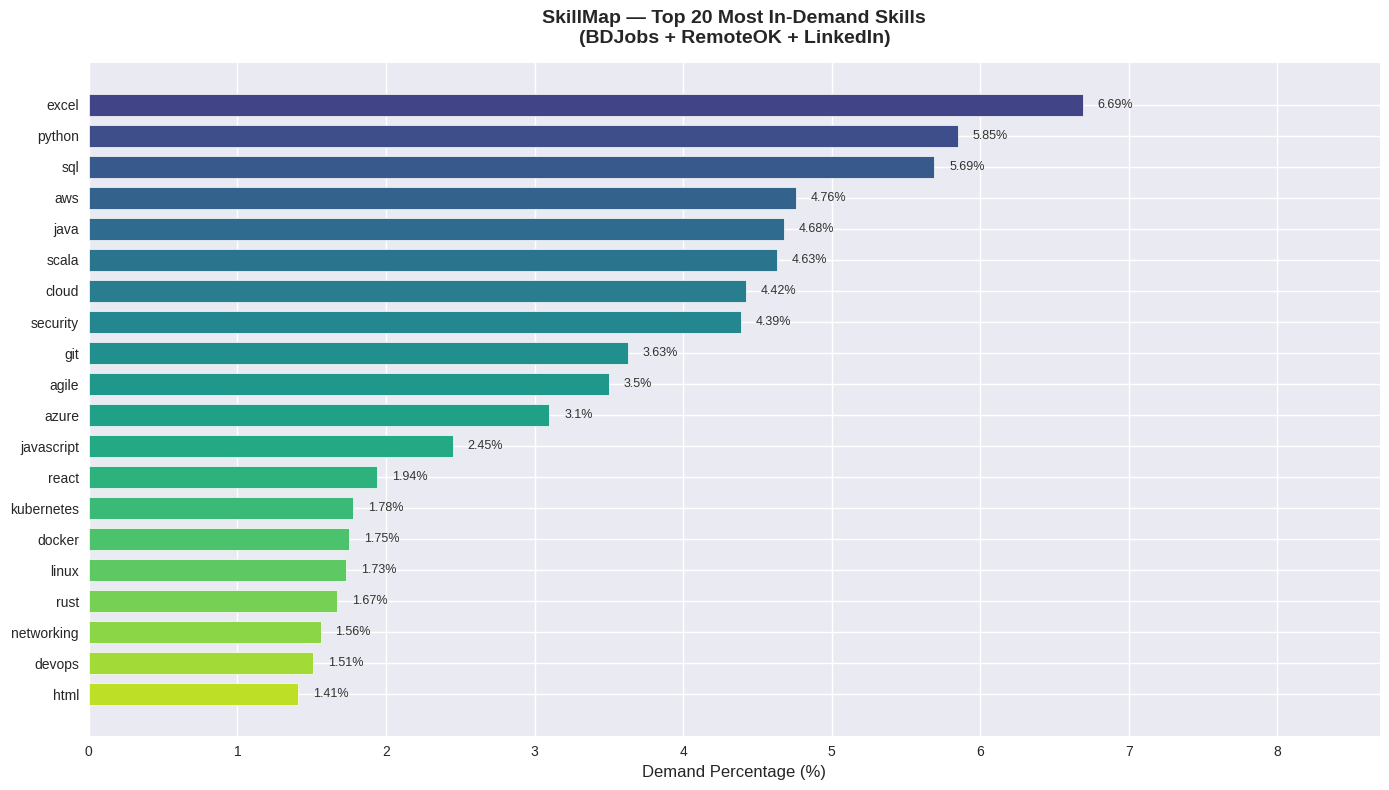

Bar chart saved!


In [23]:
# ============================================================
# SKILLMAP -- Bar Chart
# ============================================================

print("Creating bar chart...")

top20  = df_skills.head(20)
colors = plt.cm.viridis(
    np.linspace(0.2, 0.9, len(top20))
)[::-1]

fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(
    top20['skill'][::-1],
    top20['percentage'][::-1],
    color=colors,
    edgecolor='white',
    linewidth=0.5,
    height=0.7
)

for bar, pct in zip(bars, top20['percentage'][::-1]):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{pct}%',
        va='center', fontsize=9, color='#333333'
    )

ax.set_xlabel('Demand Percentage (%)', fontsize=12)
ax.set_title(
    'SkillMap — Top 20 Most In-Demand Skills\n'
    '(BDJobs + RemoteOK + LinkedIn)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlim(0, top20['percentage'].max() + 2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(
    f"{PATHS['charts']}/skill_frequency_chart.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Bar chart saved!")


##Word Cloud

Creating word cloud...


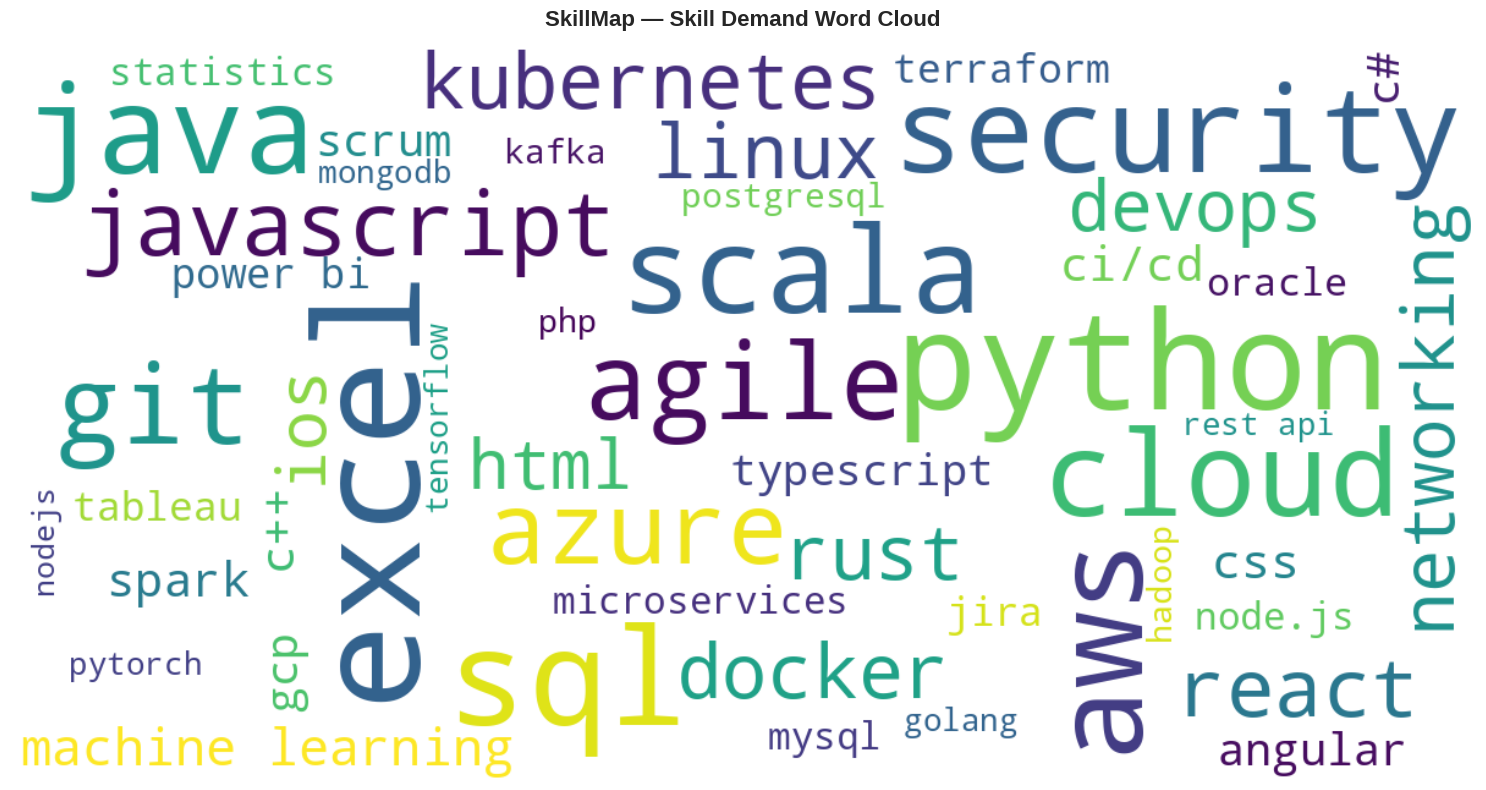

Word cloud saved!

Section 4 Complete!


In [24]:
# ============================================================
# SKILLMAP -- Word Cloud
# ============================================================

print("Creating word cloud...")

skill_freq = dict(zip(df_skills['skill'], df_skills['count']))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis',
    max_words=80,
    min_font_size=10,
    max_font_size=120,
    prefer_horizontal=0.8,
    collocations=False
).generate_from_frequencies(skill_freq)

fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title(
    'SkillMap — Skill Demand Word Cloud',
    fontsize=16, fontweight='bold', pad=15
)

plt.tight_layout()
plt.savefig(
    f"{PATHS['charts']}/skill_wordcloud.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Word cloud saved!")
print("\nSection 4 Complete!")


#Section 5 — Apriori Association Rules

##Prepare Transactions

In [25]:
# ============================================================
# SKILLMAP -- Prepare Transactions
# ============================================================

print("Preparing skill transactions...")

# Use top 30 skills only — prevents overfitting
top30_skills = [s[0] for s in skill_counts.most_common(30)]

transactions = []
for skills_text in df_master['skills'].dropna():
    skill_list = extract_skills(skills_text)
    filtered   = [s for s in skill_list if s in top30_skills]
    if len(filtered) >= 2:
        transactions.append(filtered)

print(f"Transactions prepared!")
print(f"Total transactions: {len(transactions)}")
print(f"Top 30 skills used: {top30_skills[:10]}...")
print(f"\nSample transactions:")
for t in transactions[:3]:
    print(f"→ {t}")


Preparing skill transactions...
Transactions prepared!
Total transactions: 898
Top 30 skills used: ['excel', 'python', 'sql', 'aws', 'java', 'scala', 'cloud', 'security', 'git', 'agile']...

Sample transactions:
→ ['sql', 'excel']
→ ['excel', 'agile']
→ ['excel', 'agile', 'cloud']


##Run Apriori

In [26]:
# ============================================================
# SKILLMAP -- Run Apriori
# ============================================================

print("Running Apriori algorithm...")

te       = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_enc   = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets = apriori(
    df_enc,
    min_support=0.05,
    use_colnames=True,
    max_len=2
)

print(f"Frequent itemsets found: {len(frequent_itemsets)}")

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.5
)

rules = rules.sort_values('lift', ascending=False)

rules_clean = rules[[
    'antecedents', 'consequents',
    'support', 'confidence', 'lift'
]].copy()

rules_clean['antecedents'] = rules_clean['antecedents'].apply(
    lambda x: ', '.join(list(x))
)
rules_clean['consequents'] = rules_clean['consequents'].apply(
    lambda x: ', '.join(list(x))
)
rules_clean['support']    = rules_clean['support'].round(3)
rules_clean['confidence'] = rules_clean['confidence'].round(3)
rules_clean['lift']       = rules_clean['lift'].round(3)

rules_clean.to_csv(
    f"{PATHS['results']}/association_rules.csv",
    index=False
)

print(f"Association rules generated!")
print(f"Total rules: {len(rules_clean)}")


Running Apriori algorithm...
Frequent itemsets found: 118
Association rules generated!
Total rules: 32


##Show Top Rules

In [27]:
# ============================================================
# SKILLMAP -- Show Top Rules
# ============================================================

print("\nTOP 15 SKILL ASSOCIATION RULES")
print("=" * 65)
print(f"{'If Skill':<22}{'→'} {'Then Skill':<22}{'Conf':>8}{'Lift':>8}")
print("-" * 65)
for _, row in rules_clean.head(15).iterrows():
    print(
        f"{row['antecedents']:<22}→ "
        f"{row['consequents']:<22}"
        f"{row['confidence']:>7.1%}"
        f"{row['lift']:>8.2f}"
    )
print("=" * 65)



TOP 15 SKILL ASSOCIATION RULES
If Skill              → Then Skill                Conf    Lift
-----------------------------------------------------------------
html                  → css                     72.4%    8.56
css                   → html                    82.9%    8.56
kubernetes            → docker                  64.5%    5.37
docker                → kubernetes              65.7%    5.37
html                  → javascript              75.9%    4.57
css                   → javascript              73.7%    4.44
scrum                 → agile                   90.3%    3.88
react                 → javascript              57.4%    3.46
javascript            → java                    92.6%    2.94
angular               → java                    90.2%    2.86
networking            → security                69.4%    2.40
html                  → java                    74.7%    2.37
react                 → java                    71.3%    2.26
css                   → java     

##Visualize Rules

Creating association rules chart...


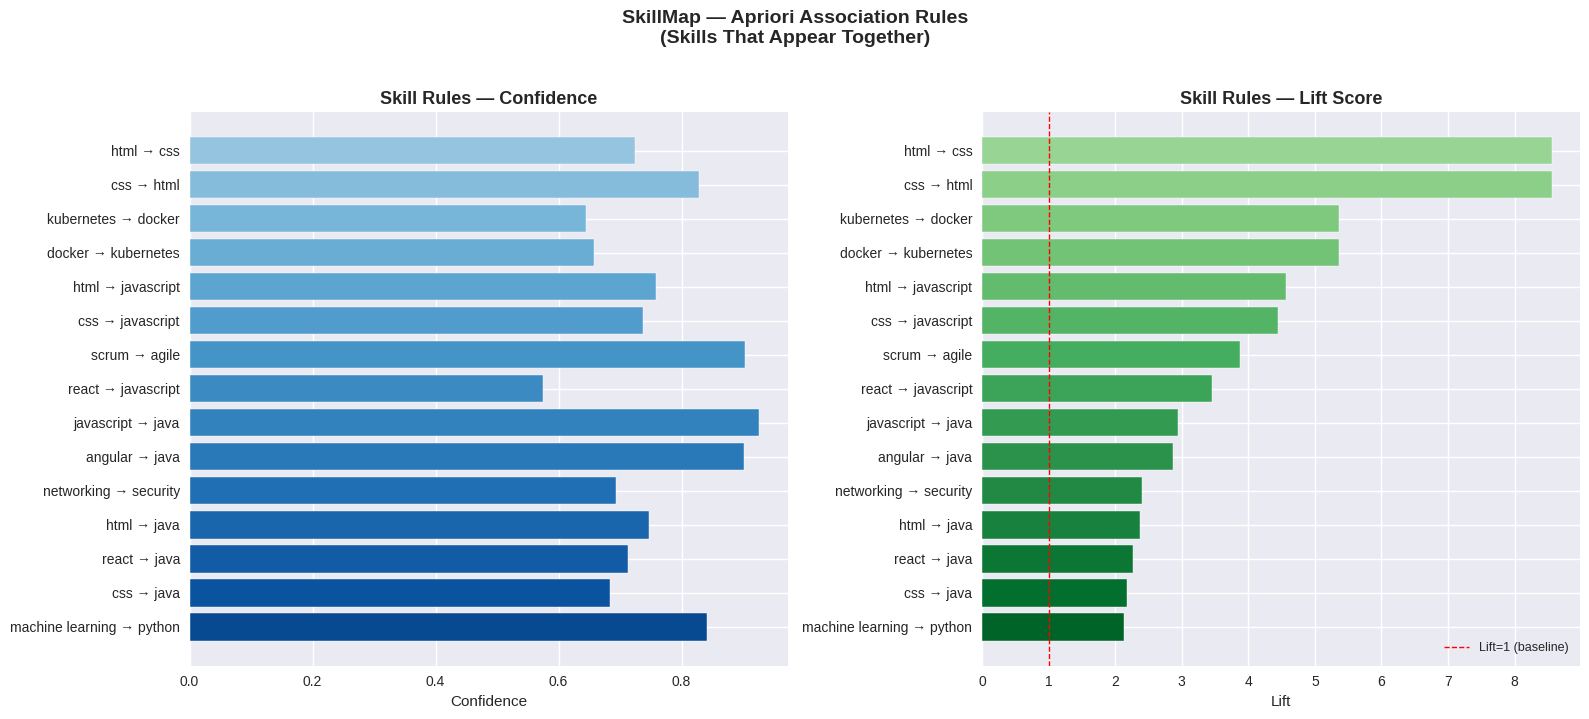

Association rules chart saved!

Section 5 Complete!


In [28]:
# ============================================================
# SKILLMAP -- Visualize Rules
# ============================================================

print("Creating association rules chart...")

top_rules        = rules_clean.head(15).copy()
top_rules['rule'] = (
    top_rules['antecedents'] + ' → ' + top_rules['consequents']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1 — Confidence
colors1 = plt.cm.Blues(
    np.linspace(0.4, 0.9, len(top_rules))
)[::-1]
axes[0].barh(
    top_rules['rule'][::-1],
    top_rules['confidence'][::-1],
    color=colors1, edgecolor='white'
)
axes[0].set_xlabel('Confidence', fontsize=11)
axes[0].set_title(
    'Skill Rules — Confidence',
    fontsize=13, fontweight='bold'
)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Chart 2 — Lift
colors2 = plt.cm.Greens(
    np.linspace(0.4, 0.9, len(top_rules))
)[::-1]
axes[1].barh(
    top_rules['rule'][::-1],
    top_rules['lift'][::-1],
    color=colors2, edgecolor='white'
)
axes[1].set_xlabel('Lift', fontsize=11)
axes[1].set_title(
    'Skill Rules — Lift Score',
    fontsize=13, fontweight='bold'
)
axes[1].axvline(
    x=1, color='red', linestyle='--',
    linewidth=1, label='Lift=1 (baseline)'
)
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle(
    'SkillMap — Apriori Association Rules\n'
    '(Skills That Appear Together)',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    f"{PATHS['charts']}/association_rules_chart.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Association rules chart saved!")
print("\nSection 5 Complete!")


#Section 6 — K-Means Clustering (Job Segmentation)

##Prepare Clustering Features

In [29]:
# ============================================================
# SKILLMAP -- Prepare Clustering Features
# ============================================================

print("Preparing features for clustering...")

def count_skills(skills_text):
    if pd.isnull(skills_text) or str(skills_text).strip() == '' or str(skills_text).strip().lower() == 'not specified':
        return 0
    try:
        if str(skills_text).strip().startswith('['):
            skill_list = ast.literal_eval(str(skills_text))
            return len([s for s in skill_list if s])
        else:
            return len([s for s in re.split(r'[,;|]', str(skills_text)) if s.strip()])
    except:
        return 1

df_cluster = df_master.copy()
df_cluster['num_skills'] = df_cluster['skills'].apply(count_skills)

# Ordinal-encode experience level
exp_map = {
    'Entry level': 0, 'Associate': 0.5, 'Mid level': 1, 'Mid-Senior level': 1.5,
    'Senior level': 2, 'Director': 2.5, 'Executive': 3, 'Internship': 0,
    'Not Specified': 1
}
df_cluster['exp_encoded'] = df_cluster['experience_level'].map(exp_map).fillna(1)

# Ordinal-encode remote status
remote_map = {'On-site': 0, 'Hybrid': 1, 'Remote': 2}
df_cluster['remote_encoded'] = df_cluster['is_remote'].map(remote_map).fillna(0)

# Only cluster rows with a real (normalized) salary value
df_cluster = df_cluster[df_cluster['salary_usd_annual'] > 0].reset_index(drop=True)

feature_cols = ['salary_usd_annual', 'num_skills', 'exp_encoded', 'remote_encoded']
features = df_cluster[feature_cols]

print(f"Feature set prepared for {len(df_cluster)} jobs")
print(features.describe().round(2))


Preparing features for clustering...
Feature set prepared for 523 jobs
       salary_usd_annual  num_skills  exp_encoded  remote_encoded
count             523.00      523.00       523.00          523.00
mean            92498.19        5.51         1.08            0.49
std             71069.08        3.19         0.56            0.83
min                33.00        0.00         0.00            0.00
25%             17338.78        3.50         1.00            0.00
50%             81550.00        4.00         1.00            0.00
75%            140000.00        8.00         1.50            1.00
max            393500.00       20.00         2.50            2.00


##Find Optimal K (Elbow Method)

Scaling features and testing cluster counts...


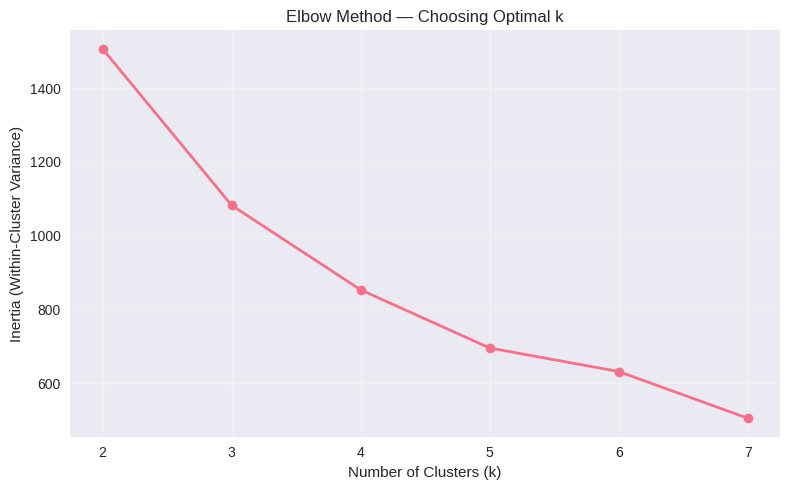

Elbow chart saved!
We select k=4 to match our 4 target job segments:
Entry-Level / Mid-Level / Senior-Level / Remote High-Salary


In [30]:
# ============================================================
# SKILLMAP -- Find Optimal K (Elbow Method)
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Scaling features and testing cluster counts...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias, marker='o', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Variance)')
plt.title('Elbow Method — Choosing Optimal k')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PATHS['charts']}/kmeans_elbow.png", dpi=150, bbox_inches='tight')
plt.show()

print("Elbow chart saved!")
print("We select k=4 to match our 4 target job segments:")
print("Entry-Level / Mid-Level / Senior-Level / Remote High-Salary")


##Run K-Means & Auto-Label Clusters

In [31]:
# ============================================================
# SKILLMAP -- Run K-Means & Auto-Label Clusters
# ============================================================

K_FINAL = 4

print(f"Running K-Means with k={K_FINAL}...")

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

centroid_df = df_cluster.groupby('cluster')[feature_cols].mean()

# The "Remote / Flexible" cluster = highest average remote_encoded
remote_cluster_id = centroid_df['remote_encoded'].idxmax()

# Remaining 3 clusters ranked by salary -> Lower / Mid / Higher salary tier
remaining = centroid_df.drop(index=remote_cluster_id).sort_values('salary_usd_annual')
salary_labels = [
    'Lower-Salary Roles (Entry-Level Range)',
    'Mid-Salary Roles',
    'Higher-Salary Roles (Senior-Level Range)'
]

label_map = {remote_cluster_id: 'Remote / Flexible Roles'}
for cid, lbl in zip(remaining.index, salary_labels):
    label_map[cid] = lbl

df_cluster['cluster_label'] = df_cluster['cluster'].map(label_map)

print("Clusters labeled!")
print(f"\nCluster centroids:")
print(centroid_df.round(2))
print(f"\nCluster sizes:")
print(df_cluster['cluster_label'].value_counts().to_string())
print(f"\n Labels are ranked by SALARY, not stated experience_level —")
print(f"experience_level is 'Not Specified' for a large share of postings,")
print(f"so salary (which K-Means actually separated on) gives a more")
print(f"reliable and non-contradictory ordering.")

df_cluster.to_csv(f"{PATHS['results']}/job_clusters.csv", index=False)
print(f"\nCluster assignments saved!")


Running K-Means with k=4...
Clusters labeled!

Cluster centroids:
         salary_usd_annual  num_skills  exp_encoded  remote_encoded
cluster                                                            
0                 85258.88        4.40         0.13            0.03
1                 45071.16        3.59         1.33            0.14
2                165438.62        7.50         1.41            0.03
3                 48615.54        5.86         1.00            1.99

Cluster sizes:
cluster_label
Higher-Salary Roles (Senior-Level Range)    173
Lower-Salary Roles (Entry-Level Range)      147
Remote / Flexible Roles                     114
Mid-Salary Roles                             89

 Labels are ranked by SALARY, not stated experience_level —
experience_level is 'Not Specified' for a large share of postings,
so salary (which K-Means actually separated on) gives a more
reliable and non-contradictory ordering.

Cluster assignments saved!


##Visualize Clusters (PCA Scatter Plot)

Reducing to 2D with PCA for visualization...


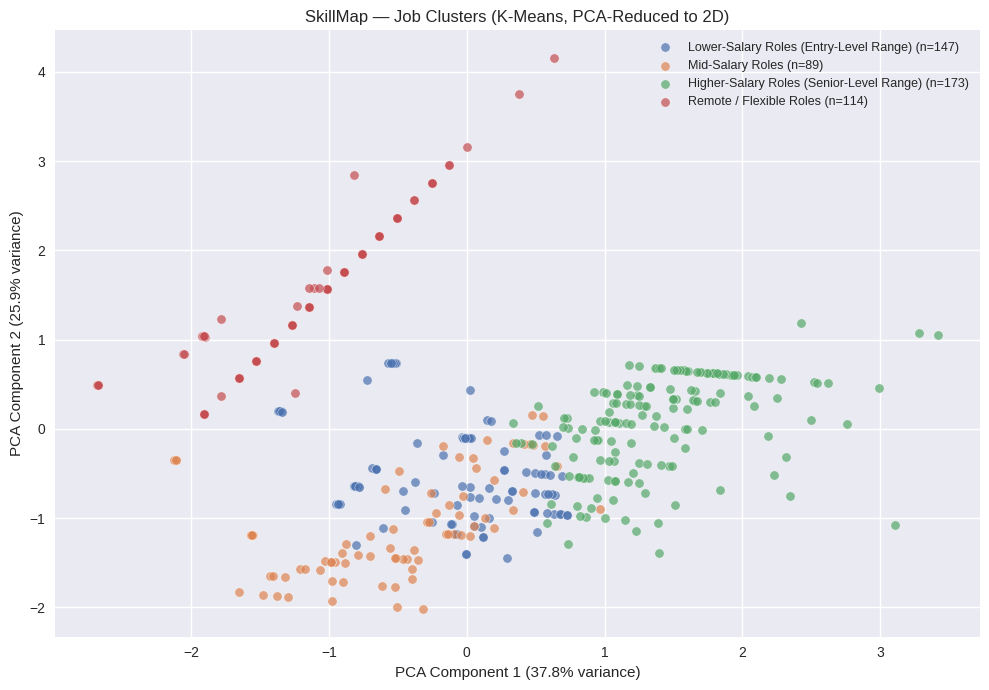

Cluster scatter plot saved!
Cluster assignments re-saved with pca1/pca2 columns included!

CLUSTER PROFILE SUMMARY
                                          count  avg_salary_usd  avg_skills  \
cluster_label                                                                 
Higher-Salary Roles (Senior-Level Range)    173        165438.6         7.5   
Lower-Salary Roles (Entry-Level Range)      147         45071.2         3.6   
Mid-Salary Roles                             89         85258.9         4.4   
Remote / Flexible Roles                     114         48615.5         5.9   

                                          pct_remote  
cluster_label                                         
Higher-Salary Roles (Senior-Level Range)         1.7  
Lower-Salary Roles (Entry-Level Range)          14.3  
Mid-Salary Roles                                 3.4  
Remote / Flexible Roles                        100.0  

Section 6 Complete!


In [32]:
# ============================================================
# SKILLMAP -- Visualize Clusters (PCA Scatter Plot)
# ============================================================

from sklearn.decomposition import PCA

print("Reducing to 2D with PCA for visualization...")

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_cluster['pca1'] = X_pca[:, 0]
df_cluster['pca2'] = X_pca[:, 1]

palette = {
    'Lower-Salary Roles (Entry-Level Range)': '#4C72B0',
    'Mid-Salary Roles': '#DD8452',
    'Higher-Salary Roles (Senior-Level Range)': '#55A868',
    'Remote / Flexible Roles': '#C44E52'
}

plt.figure(figsize=(10, 7))
for label, color in palette.items():
    subset = df_cluster[df_cluster['cluster_label'] == label]
    plt.scatter(
        subset['pca1'], subset['pca2'],
        label=f"{label} (n={len(subset)})",
        alpha=0.7, s=45, color=color,
        edgecolor='white', linewidth=0.4
    )

plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('SkillMap — Job Clusters (K-Means, PCA-Reduced to 2D)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{PATHS['charts']}/kmeans_clusters_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

df_cluster.to_csv(f"{PATHS['results']}/job_clusters.csv", index=False)

print("Cluster scatter plot saved!")
print("Cluster assignments re-saved with pca1/pca2 columns included!")
print(f"\nCLUSTER PROFILE SUMMARY")
print("=" * 60)
summary = df_cluster.groupby('cluster_label').agg(
    count=('cluster', 'size'),
    avg_salary_usd=('salary_usd_annual', 'mean'),
    avg_skills=('num_skills', 'mean'),
    pct_remote=('remote_encoded', lambda x: (x >= 1).mean() * 100)
).round(1)
print(summary)
print("=" * 60)
print("\nSection 6 Complete!")


#Section 7 — Hiring Trend Analysis (Simulated)

##Simulate 6-Month Posting Trend


In [33]:
# ============================================================
# SKILLMAP -- Simulate Hiring Trend (Jan 2026 to Current Month)
# ============================================================

print("Simulating hiring trend (Jan 2026 to current month)...")

np.random.seed(42)

months = pd.date_range(
    start='2026-01-01',
    end=pd.Timestamp.today().normalize().replace(day=1),
    freq='MS'
)
month_labels = [m.strftime('%b %Y') for m in months]


growth_profiles = {
    'BDJobs': (0.10, 0.018),    # steady local market growth
    'RemoteOK': (0.08, 0.022),  # faster growth, remote-work demand
    'LinkedIn': (0.14, 0.010),  # slow steady growth
}

trend_rows = []
for source, (start_weight, growth_rate) in growth_profiles.items():
    weights = np.array([start_weight + growth_rate * i for i in range(len(months))])
    weights = weights / weights.sum()
    n_jobs = len(df_master[df_master['source'] == source])
    counts = np.random.multinomial(n_jobs, weights)
    for month_label, count in zip(month_labels, counts):
        trend_rows.append({'month': month_label, 'source': source, 'job_count': int(count)})

df_trend = pd.DataFrame(trend_rows)
df_trend.to_csv(f"{PATHS['results']}/hiring_trend_simulated.csv", index=False)

print(f"\nSimulated trend data created for {len(month_labels)} months")
print(df_trend.pivot(index='month', columns='source', values='job_count').reindex(month_labels))


Simulating hiring trend (Jan 2026 to current month)...

Simulated trend data created for 9 months
source    BDJobs  LinkedIn  RemoteOK
month                               
Jan 2026       7        83         5
Feb 2026      15        95         8
Mar 2026      13        83         3
Apr 2026      13       102        15
May 2026      10       106        13
Jun 2026      12       108         8
Jul 2026      13       104        10
Aug 2026      26       117        13
Sep 2026      20       150        19


##Visualize Hiring Trend

Creating hiring trend chart...


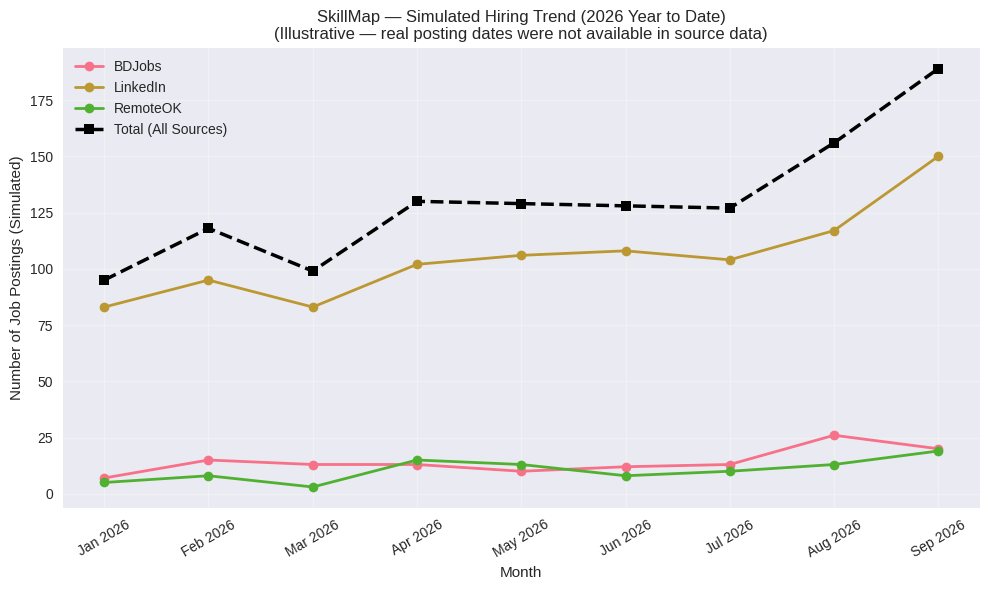

Hiring trend chart saved!

Section 7 Complete!


In [34]:
# ============================================================
# SKILLMAP -- Visualize Hiring Trend
# ============================================================

print("Creating hiring trend chart...")

pivot_trend = df_trend.pivot(index='month', columns='source', values='job_count').reindex(month_labels)

plt.figure(figsize=(10, 6))
for source in pivot_trend.columns:
    plt.plot(pivot_trend.index, pivot_trend[source], marker='o', linewidth=2, label=source)

total_line = pivot_trend.sum(axis=1)
plt.plot(pivot_trend.index, total_line, marker='s', linewidth=2.5,
          linestyle='--', color='black', label='Total (All Sources)')

plt.xlabel('Month')
plt.ylabel('Number of Job Postings (Simulated)')
plt.title(
    'SkillMap — Simulated Hiring Trend (2026 Year to Date)\n'
    '(Illustrative — real posting dates were not available in source data)'
)
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{PATHS['charts']}/hiring_trend_chart.png", dpi=150, bbox_inches='tight')
plt.show()

print("Hiring trend chart saved!")
print("\nSection 7 Complete!")


#Section 8 — Skill Gap Analysis (Resume vs Job Market)

##Load Resume Dataset

In [35]:
# ============================================================
# SKILLMAP -- Load Resume Dataset
# ============================================================

df_resume_raw = pd.read_csv(PATHS['resume'])
print(f"Total resumes: {len(df_resume_raw)}")

df_resume_raw = df_resume_raw[df_resume_raw['skills'].notna()].copy()
print(f"Resumes with skills listed: {len(df_resume_raw)}")

# balance with the other datasets rather than using all ~9500 resumes
TARGET_RESUME_ROWS = 280
if len(df_resume_raw) > TARGET_RESUME_ROWS:
    df_resume_raw = df_resume_raw.sample(n=TARGET_RESUME_ROWS, random_state=42).reset_index(drop=True)

print(f"Resumes used for skill gap analysis: {len(df_resume_raw)}")


Total resumes: 9544
Resumes with skills listed: 9488
Resumes used for skill gap analysis: 280


##Compute Skill Supply vs Demand

In [36]:
# ============================================================
# SKILLMAP -- Compute Skill Supply vs Demand
# ============================================================

# supply side: skills candidates already have (resumes)
resume_skills = []
df_resume_raw['skills'].dropna().apply(lambda x: resume_skills.extend(extract_skills(x)))
supply_counts = Counter(resume_skills)
supply_total = len(resume_skills)

# demand side: skills employers ask for (job postings)
demand_counts = Counter(all_skills)
demand_total = len(all_skills)

# compare on the union of the top skills from each side
top_demand_skills = [s for s, _ in demand_counts.most_common(30)]
top_supply_skills = [s for s, _ in supply_counts.most_common(30)]
compare_skills = sorted(set(top_demand_skills) | set(top_supply_skills))

gap_rows = []
for skill in compare_skills:
    demand_pct = demand_counts.get(skill, 0) / demand_total * 100
    supply_pct = supply_counts.get(skill, 0) / supply_total * 100
    gap_rows.append({
        'skill': skill,
        'demand_pct': round(demand_pct, 2),
        'supply_pct': round(supply_pct, 2),
        'gap': round(demand_pct - supply_pct, 2)
    })

df_gap = pd.DataFrame(gap_rows).sort_values('gap', ascending=False).reset_index(drop=True)
df_gap.to_csv(f"{PATHS['results']}/skill_gap_analysis.csv", index=False)

print("Top skills employers want but candidates lack (positive gap):")
print(df_gap.head(10).to_string())
print()
print("Skills candidates have more of than employers ask for (negative gap):")
print(df_gap.tail(10).to_string())


Top skills employers want but candidates lack (positive gap):
      skill  demand_pct  supply_pct   gap
0     excel        6.69        0.85  5.85
1       sql        5.69        0.92  4.77
2     scala        4.63        0.02  4.62
3       aws        4.76        0.17  4.59
4     cloud        4.42        0.05  4.37
5  security        4.39        0.03  4.36
6      java        4.68        0.52  4.17
7    python        5.85        1.97  3.88
8     agile        3.50        0.02  3.48
9       git        3.63        0.24  3.39

Skills candidates have more of than employers ask for (negative gap):
                          skill  demand_pct  supply_pct   gap
43                      quality        0.00        0.41 -0.41
44                      clients        0.02        0.43 -0.42
45           project management        0.00        0.43 -0.43
46                 data science        0.00        0.45 -0.45
47                    processes        0.00        0.48 -0.48
48      artificial intelligence  

##Visualize Skill Gap

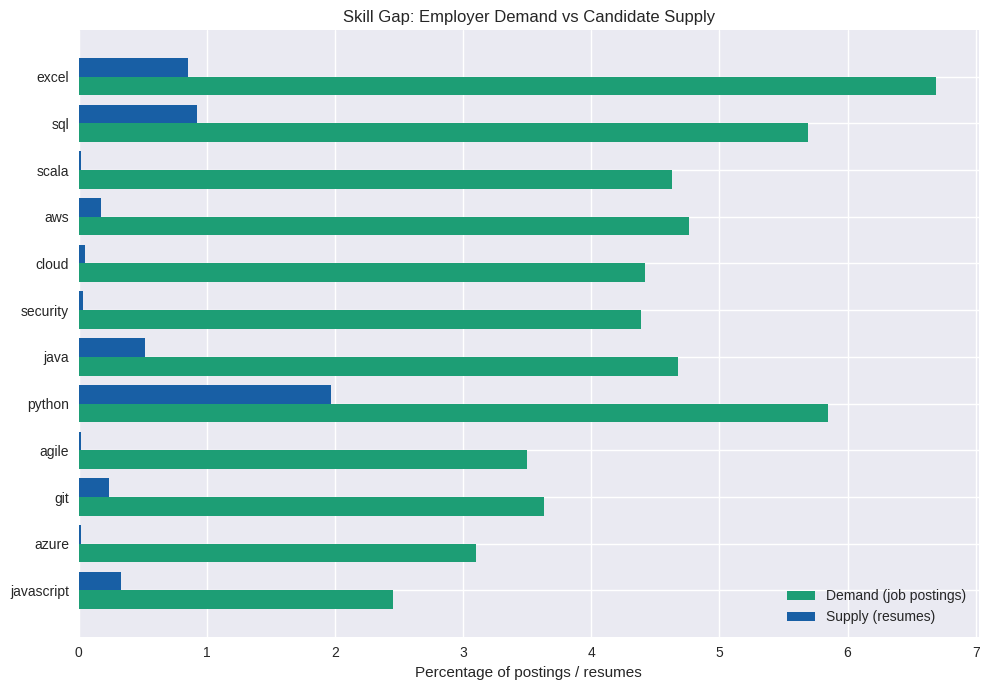

Skill gap chart saved!
Section 8 Complete!


In [37]:
# ============================================================
# SKILLMAP -- Visualize Skill Gap
# ============================================================

top_gap = df_gap.head(12).sort_values('gap')

fig, ax = plt.subplots(figsize=(10, 7))
y_pos = range(len(top_gap))
ax.barh(y_pos, top_gap['demand_pct'], height=0.4, label='Demand (job postings)', color='#1D9E75', align='edge')
ax.barh([y + 0.4 for y in y_pos], top_gap['supply_pct'], height=0.4, label='Supply (resumes)', color='#185FA5', align='edge')
ax.set_yticks([y + 0.4 for y in y_pos])
ax.set_yticklabels(top_gap['skill'])
ax.set_xlabel('Percentage of postings / resumes')
ax.set_title('Skill Gap: Employer Demand vs Candidate Supply')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PATHS['charts']}/skill_gap_chart.png", dpi=150, bbox_inches='tight')
plt.show()

print("Skill gap chart saved!")
print("Section 8 Complete!")


#Section 9 — BD vs Global Salary Comparison

##Compare Average Salaries by Market

In [38]:
# ============================================================
# SKILLMAP -- Compare Average Salaries by Market
# ============================================================

paid = df_master[df_master['salary_usd_annual'] > 0]

bd_salaries = paid[paid['country'] == 'Bangladesh']['salary_usd_annual']
us_salaries = paid[paid['country'] == 'USA']['salary_usd_annual']
remote_salaries = paid[paid['country'] == 'Global']['salary_usd_annual']

salary_summary = pd.DataFrame({
    'market': ['Bangladesh', 'USA', 'Remote/Global'],
    'avg_salary_usd': [bd_salaries.mean(), us_salaries.mean(), remote_salaries.mean()],
    'median_salary_usd': [bd_salaries.median(), us_salaries.median(), remote_salaries.median()],
    'count': [len(bd_salaries), len(us_salaries), len(remote_salaries)]
}).round(0)

salary_summary.to_csv(f"{PATHS['results']}/salary_comparison.csv", index=False)
print(salary_summary.to_string(index=False))


       market  avg_salary_usd  median_salary_usd  count
   Bangladesh          6888.0             5878.0    129
          USA        136493.0           134358.0    300
Remote/Global         69575.0            60000.0     94


##Visualize Salary Comparison

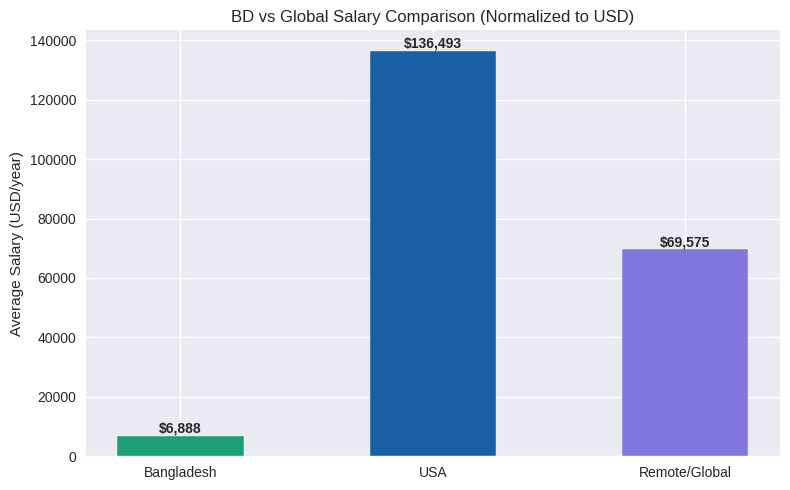

Remote jobs pay 10.1x the average Bangladesh salary
USA jobs pay 19.8x the average Bangladesh salary
Salary comparison chart saved!
Section 9 Complete!


In [39]:
# ============================================================
# SKILLMAP -- Visualize Salary Comparison
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(salary_summary['market'], salary_summary['avg_salary_usd'],
               color=['#1D9E75', '#185FA5', '#7F77DD'], width=0.5, edgecolor='white')
for bar, val in zip(bars, salary_summary['avg_salary_usd']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
            f"${val:,.0f}", ha='center', fontweight='bold')
ax.set_ylabel('Average Salary (USD/year)')
ax.set_title('BD vs Global Salary Comparison (Normalized to USD)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PATHS['charts']}/salary_comparison_chart.png", dpi=150, bbox_inches='tight')
plt.show()

remote_multiplier = salary_summary.loc[salary_summary['market'] == 'Remote/Global', 'avg_salary_usd'].values[0] / \
                     salary_summary.loc[salary_summary['market'] == 'Bangladesh', 'avg_salary_usd'].values[0]
us_multiplier = salary_summary.loc[salary_summary['market'] == 'USA', 'avg_salary_usd'].values[0] / \
                 salary_summary.loc[salary_summary['market'] == 'Bangladesh', 'avg_salary_usd'].values[0]

print(f"Remote jobs pay {remote_multiplier:.1f}x the average Bangladesh salary")
print(f"USA jobs pay {us_multiplier:.1f}x the average Bangladesh salary")
print("Salary comparison chart saved!")
print("Section 9 Complete!")


#Section 10 — Recommendations Engine

##Build Recommendation Rules

In [40]:
# ============================================================
# SKILLMAP -- Build Recommendation Rules
# ============================================================

def generate_recommendations(user_skills, market='Bangladesh'):
    user_skills = set(s.strip().lower() for s in user_skills)
    recs = []

    # market-specific top skills
    market_df = df_master[df_master['country'] == market] if market in ('Bangladesh', 'USA') \
        else df_master[df_master['country'] == 'Global']
    market_skills = []
    market_df['skills'].dropna().apply(lambda x: market_skills.extend(extract_skills(x)))
    market_counts = Counter(market_skills)
    market_total = len(market_df)

    missing_top = [(s, c) for s, c in market_counts.most_common(10) if s not in user_skills]
    if missing_top:
        skill, count = missing_top[0]
        pct = count / len(market_skills) * 100
        recs.append(f"Learn {skill} -- it appears in {pct:.0f}% of {market} skill mentions")

    # association rules: what pairs well with a skill the user already has
    for skill in user_skills:
        matches = rules_clean[rules_clean['antecedents'] == skill]
        if len(matches) > 0:
            best = matches.sort_values('lift', ascending=False).iloc[0]
            if best['consequents'] not in user_skills:
                recs.append(
                    f"{skill} and {best['consequents']} often appear together "
                    f"(confidence {best['confidence']*100:.0f}%) -- consider adding {best['consequents']}"
                )
            break

    # skill gap: high-demand, low-supply skills worth learning
    top_gap_skill = df_gap[~df_gap['skill'].isin(user_skills)].sort_values('gap', ascending=False)
    if len(top_gap_skill) > 0:
        row = top_gap_skill.iloc[0]
        recs.append(f"{row['skill']} is in high demand but relatively rare among candidates (gap: {row['gap']:.1f} points)")

    # salary insight
    if market == 'Bangladesh':
        recs.append(f"Remote jobs pay {remote_multiplier:.1f}x the average Bangladesh salary for similar roles")

    # coverage: how many of the user's skills match this market's top 20
    market_top20 = set(s for s, _ in market_counts.most_common(20))
    overlap = user_skills & market_top20
    coverage_pct = len(overlap) / max(len(market_top20), 1) * 100
    recs.append(f"Your current skills cover {coverage_pct:.0f}% of the top 20 skills requested in {market}")

    return recs

sample_skills = ['python', 'sql']
sample_recs = generate_recommendations(sample_skills, market='Bangladesh')

print(f"Sample recommendations for skills {sample_skills} in Bangladesh market:")
for r in sample_recs:
    print(f"- {r}")

print()
print("Section 10 Complete!")


Sample recommendations for skills ['python', 'sql'] in Bangladesh market:
- Learn networking -- it appears in 3% of Bangladesh skill mentions
- excel is in high demand but relatively rare among candidates (gap: 5.8 points)
- Remote jobs pay 10.1x the average Bangladesh salary for similar roles
- Your current skills cover 10% of the top 20 skills requested in Bangladesh

Section 10 Complete!


## Section 11 — RNN vs Logistic Regression (Skill-Based Experience Level Prediction)

**Comparison:**
- **Logistic Regression + TF-IDF** — classical baseline (treats skills as unordered bag of words)
- **RNN (Bidirectional LSTM)** — deep learning model (reads skills as a sequence, capturing skill combinations)

### Step 1 — Prepare Data

In [41]:
# ============================================================
# SKILLMAP -- Section 11 — Step 1: Prepare Data
# ============================================================

import numpy as np
import warnings
warnings.filterwarnings('ignore')

df_rnn = df_master.copy()

# Map experience level to 3 classes
level_map = {
    'Entry level': 0,
    'Mid-Senior level': 1,
    'Senior level': 1,
    'Director': 2,
    'Not Specified': -1
}
df_rnn['label'] = df_rnn['experience_level'].map(level_map).fillna(-1).astype(int)
df_rnn = df_rnn[df_rnn['label'] >= 0].reset_index(drop=True)
df_rnn['skill_text'] = df_rnn['skills'].fillna('').astype(str)
df_rnn = df_rnn[df_rnn['skill_text'].str.len() > 5].reset_index(drop=True)

class_names = {0: 'Entry', 1: 'Mid/Senior', 2: 'Director'}
print("Data ready!")
print(f"Total samples : {len(df_rnn)}")
for k, v in class_names.items():
    n = (df_rnn['label'] == k).sum()
    print(f"  {v:<12}: {n} samples ({n/len(df_rnn)*100:.1f}%)")

Data ready!
Total samples : 628
  Entry       : 144 samples (22.9%)
  Mid/Senior  : 468 samples (74.5%)
  Director    : 16 samples (2.5%)


### Step 2 — Install & Import Libraries

In [42]:
# ============================================================
# SKILLMAP -- Section 11 — Step 2: Install Libraries
# ============================================================

try:
    import tensorflow as tf
    print(f"TensorFlow: v{tf.__version__}")
except ImportError:
    !pip install tensorflow -q
    import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, Bidirectional,
                                     LSTM, Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries ready!")

TensorFlow: v2.20.0
Libraries ready!


### Step 3 — Tokenize & Split

In [43]:
# ============================================================
# SKILLMAP -- Section 11 — Step 3: Tokenize & Split
# ============================================================

MAX_VOCAB = 400
MAX_LEN   = 25

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>", lower=True)
tokenizer.fit_on_texts(df_rnn['skill_text'])

X = pad_sequences(
    tokenizer.texts_to_sequences(df_rnn['skill_text']),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
y = df_rnn['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# prepare raw text split for Logistic Regression
texts = df_rnn['skill_text'].values
idx   = np.arange(len(texts))
tr_idx, te_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)

print(f"Vocabulary size : {min(MAX_VOCAB, len(tokenizer.word_index))}")
print(f"Train samples   : {len(X_train)}")
print(f"Test samples    : {len(X_test)}")

Vocabulary size : 400
Train samples   : 502
Test samples    : 126


### Step 4 — Baseline: Logistic Regression

In [44]:
# ============================================================
# SKILLMAP -- Section 11 — Step 4: Logistic Regression Baseline
# ============================================================

tfidf    = TfidfVectorizer(max_features=400, ngram_range=(1, 2))
X_tr_tfi = tfidf.fit_transform(texts[tr_idx])
X_te_tfi = tfidf.transform(texts[te_idx])

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_tr_tfi, y[tr_idx])
lr_preds    = lr.predict(X_te_tfi)
lr_accuracy = accuracy_score(y[te_idx], lr_preds)

print(f"Logistic Regression Accuracy: {lr_accuracy*100:.2f}%")
print()
print(classification_report(y[te_idx], lr_preds,
      target_names=["Entry","Mid/Senior","Director"]))

Logistic Regression Accuracy: 70.63%

              precision    recall  f1-score   support

       Entry       0.14      0.03      0.06        29
  Mid/Senior       0.74      0.94      0.83        94
    Director       0.00      0.00      0.00         3

    accuracy                           0.71       126
   macro avg       0.29      0.32      0.29       126
weighted avg       0.58      0.71      0.63       126



### Step 5 — RNN: Bidirectional LSTM

In [45]:
# ============================================================
# SKILLMAP -- Section 11 — Step 5: Build & Train RNN (BiLSTM)
# ============================================================

import tensorflow as tf
NUM_CLASSES = len(np.unique(y))
vocab_size  = min(MAX_VOCAB, len(tokenizer.word_index) + 1)

# Build model with explicit Input layer — fixes "unbuilt" display
inputs  = tf.keras.Input(shape=(MAX_LEN,), name='skill_input')
x       = tf.keras.layers.Embedding(vocab_size, 32, name='embedding')(inputs)
x       = tf.keras.layers.Bidirectional(
              tf.keras.layers.LSTM(64, dropout=0.3, recurrent_dropout=0.2),
              name='bilstm'
          )(x)
x       = tf.keras.layers.Dropout(0.4, name='dropout')(x)
x       = tf.keras.layers.Dense(32, activation='relu', name='dense')(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', name='output')(x)

rnn_model = tf.keras.Model(inputs=inputs, outputs=outputs, name='SkillMap_BiLSTM')

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
rnn_model.summary()

history = rnn_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=16,
    validation_split=0.15,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3,
                             restore_best_weights=True)],
    verbose=1
)
print("RNN training complete!")

Model: "SkillMap_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skill_input (InputLayer)        │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 25, 32)         │        12,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 128)            │        49,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,691 (260.51 KB)

 Trainable params: 66,691 (260.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 232ms/step - accuracy: 0.7066 - loss: 0.8668 - val_accuracy: 0.8289 - val_loss: 0.5208
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - accuracy: 0.7277 - loss: 0.7105 - val_accuracy: 0.8289 - val_loss: 0.5188
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - accuracy: 0.7300 - loss: 0.6844 - val_accuracy: 0.8289 - val_loss: 0.5254
Epoch 4/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 204ms/step - accuracy: 0.7300 - loss: 0.6816 - val_accuracy: 0.8289 - val_loss: 0.5395
Epoch 5/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 207ms/step - accuracy: 0.7300 - loss: 0.6841 - val_accuracy: 0.8289 - val_loss: 0.5207
RNN training complete!


### Step 6 — Evaluate & Compare

In [46]:
# ============================================================
# SKILLMAP -- Section 11 — Step 6: Evaluate & Compare
# ============================================================

rnn_preds    = np.argmax(rnn_model.predict(X_test, verbose=0), axis=1)
rnn_accuracy = accuracy_score(y_test, rnn_preds)

print("=" * 48)
print("         MODEL COMPARISON RESULTS")
print("=" * 48)
print(f"  Logistic Regression  : {lr_accuracy*100:.2f}%")
print(f"  RNN (BiLSTM)         : {rnn_accuracy*100:.2f}%")
diff = rnn_accuracy - lr_accuracy
if diff > 0:
    print(f"  RNN is better by     : +{diff*100:.2f}%")
else:
    print(f"  LR is better by      : +{abs(diff)*100:.2f}%")
print("=" * 48)
print()
print("RNN Classification Report:")
print(classification_report(y_test, rnn_preds,
      target_names=["Entry","Mid/Senior","Director"]))

# Save results
pd.DataFrame([
    {"Model":"Logistic Regression","Accuracy":round(lr_accuracy*100,2)},
    {"Model":"RNN (BiLSTM)",       "Accuracy":round(rnn_accuracy*100,2)},
]).to_csv(f"{PATHS['results']}/rnn_comparison.csv", index=False)
print("Results saved!")

         MODEL COMPARISON RESULTS
  Logistic Regression  : 70.63%
  RNN (BiLSTM)         : 74.60%
  RNN is better by     : +3.97%

RNN Classification Report:
              precision    recall  f1-score   support

       Entry       0.00      0.00      0.00        29
  Mid/Senior       0.75      1.00      0.85        94
    Director       0.00      0.00      0.00         3

    accuracy                           0.75       126
   macro avg       0.25      0.33      0.28       126
weighted avg       0.56      0.75      0.64       126

Results saved!


### Step 7 — Visualize Results

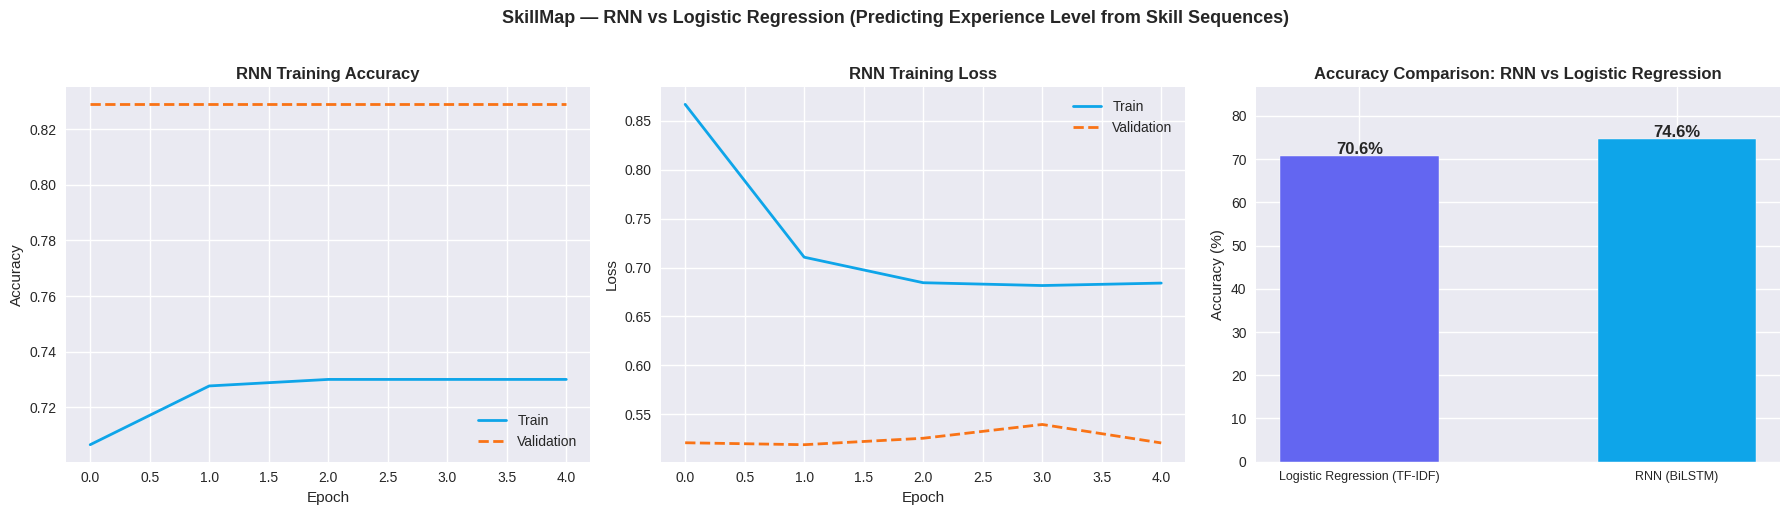

Chart saved!


In [47]:
# ============================================================
# SKILLMAP -- Section 11 — Step 7: Visualize Results
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Training accuracy curve
axes[0].plot(history.history['accuracy'],
             color='#0ea5e9', lw=2, label='Train')
axes[0].plot(history.history['val_accuracy'],
             color='#f97316', lw=2, ls='--', label='Validation')
axes[0].set_title('RNN Training Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Chart 2: Training loss curve
axes[1].plot(history.history['loss'],
             color='#0ea5e9', lw=2, label='Train')
axes[1].plot(history.history['val_loss'],
             color='#f97316', lw=2, ls='--', label='Validation')
axes[1].set_title('RNN Training Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Chart 3: Accuracy comparison bar chart
model_labels = ['Logistic Regression (TF-IDF)', 'RNN (BiLSTM)']
accuracies   = [lr_accuracy * 100, rnn_accuracy * 100]
bars = axes[2].bar(model_labels, accuracies,
                   color=['#6366f1', '#0ea5e9'],
                   width=0.5, edgecolor='white')
for bar, acc in zip(bars, accuracies):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{acc:.1f}%',
        ha='center', fontweight='bold', fontsize=12
    )
axes[2].set_ylim(0, max(accuracies) + 12)
axes[2].set_title('Accuracy Comparison: RNN vs Logistic Regression',
                  fontweight='bold')
axes[2].set_ylabel('Accuracy (%)')
axes[2].tick_params(axis='x', labelsize=9)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.suptitle(
    'SkillMap — RNN vs Logistic Regression'
    ' (Predicting Experience Level from Skill Sequences)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    f"{PATHS['charts']}/rnn_comparison.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved!")


#Section 12 — Streamlit Dashboard

##Write app.py File

##Verify Results Files Before Building Dashboard

In [48]:
# ============================================================
# SKILLMAP -- Section 12: Verify Results Files
# ============================================================

required_files = {
    'Skill frequency (Section 4)': f"{PATHS['results']}/skill_frequency.csv",
    'Association rules (Section 5)': f"{PATHS['results']}/association_rules.csv",
    'Job clusters (Section 6)': f"{PATHS['results']}/job_clusters.csv",
    'Hiring trend (Section 7)': f"{PATHS['results']}/hiring_trend_simulated.csv",
    'Skill gap (Section 8)': f"{PATHS['results']}/skill_gap_analysis.csv",
    'Salary comparison (Section 9)': f"{PATHS['results']}/salary_comparison.csv",
}

all_ok = True
for label, path in required_files.items():
    exists = os.path.exists(path)
    size_ok = exists and os.path.getsize(path) > 0
    status = "OK" if size_ok else "MISSING or EMPTY"
    print(f"{label}: {status}")
    if not size_ok:
        all_ok = False

if all_ok:
    print("\nAll result files present, safe to build the dashboard.")
else:
    print("\nSome files are missing. Re-run the relevant sections above before continuing.")


Skill frequency (Section 4): OK
Association rules (Section 5): OK
Job clusters (Section 6): OK
Hiring trend (Section 7): OK
Skill gap (Section 8): OK
Salary comparison (Section 9): OK

All result files present, safe to build the dashboard.


In [49]:
# ============================================================
# SKILLMAP -- Section 12: Write app.py
# ============================================================

DRIVE_BASE    = '/content/drive/MyDrive/SkillMap'
MASTER_CSV    = f'{DRIVE_BASE}/master_dataset.csv'
SKILLS_CSV    = f'{DRIVE_BASE}/outputs/results/skill_frequency.csv'
RULES_CSV     = f'{DRIVE_BASE}/outputs/results/association_rules.csv'
CLUSTERS_CSV  = f'{DRIVE_BASE}/outputs/results/job_clusters.csv'
TREND_CSV     = f'{DRIVE_BASE}/outputs/results/hiring_trend_simulated.csv'
GAP_CSV       = f'{DRIVE_BASE}/outputs/results/skill_gap_analysis.csv'
SALARY_CSV    = f'{DRIVE_BASE}/outputs/results/salary_comparison.csv'
CHARTS_FOLDER = f'{DRIVE_BASE}/outputs/charts'

app_code = """
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import ast
import re
import os

st.set_page_config(
    page_title="SkillMap",
    page_icon="\U0001F5FA",
    layout="wide"
)

MASTER_PATH = "__MASTER_CSV__"
SKILLS_PATH = "__SKILLS_CSV__"
RULES_PATH = "__RULES_CSV__"
CLUSTERS_PATH = "__CLUSTERS_CSV__"
TREND_PATH = "__TREND_CSV__"
GAP_PATH = "__GAP_CSV__"
SALARY_PATH = "__SALARY_CSV__"

@st.cache_data
def load_csv(path, cols=None):
    if not os.path.exists(path):
        return pd.DataFrame(columns=cols or [])
    return pd.read_csv(path)

df_master = load_csv(MASTER_PATH)
df_skills = load_csv(SKILLS_PATH, ["skill","count","percentage"])
df_rules = load_csv(RULES_PATH, ["antecedents","consequents","support","confidence","lift"])
df_clusters = load_csv(CLUSTERS_PATH)
df_trend = load_csv(TREND_PATH, ["month","source","job_count"])
df_gap = load_csv(GAP_PATH, ["skill","demand_pct","supply_pct","gap"])
df_salary = load_csv(SALARY_PATH, ["market","avg_salary_usd","median_salary_usd","count"])

if df_master.empty:
    st.error("Master dataset not found. Please run all notebook sections first.")
    st.stop()

# skill cleaner -- mirrors Section 4's cleaning rules (noise words,
# EEO boilerplate, long sentence fragments), so live in-app skill
# counts stay consistent with the offline mining
NOISE_WORDS = [
    'not specified', 'n/a', 'none', 'null',
    'not applicable', 'na', 'other', 'various'
]
EEO_BOILERPLATE = [
    'race', 'color', 'national origin', 'religion', 'sex',
    'sexual orientation', 'gender identity', 'gender expression',
    'disability', 'veteran status', 'protected veteran', 'age',
    'marital status', 'genetic information', 'equal opportunity employer',
    'without regard to', 'pregnancy', 'citizenship status'
]
MAX_SKILL_WORDS = 4

def extract_skills(skills_text):
    if pd.isnull(skills_text) or str(skills_text).strip() == "":
        return []
    try:
        if str(skills_text).strip().startswith("["):
            skill_list = ast.literal_eval(str(skills_text))
            raw = [str(s).strip().lower() for s in skill_list if s]
        else:
            raw = [s.strip().lower() for s in re.split(r"[,;|]", str(skills_text)) if s.strip()]
    except Exception:
        raw = [str(skills_text).strip().lower()]
    return [
        s for s in raw
        if s not in NOISE_WORDS and s not in EEO_BOILERPLATE
        and len(s) > 1 and len(s.split()) <= MAX_SKILL_WORDS
    ]

st.markdown('''
<style>
h1 {
    background: linear-gradient(90deg, #1D9E75, #185FA5);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-weight: 800;
    font-size: 3rem;
    padding-bottom: 0.2rem;
}
.stTabs [data-baseweb="tab-list"] button [data-testid="stMarkdownContainer"] p {
    font-size: 1.05rem;
    font-weight: 600;
}
.stTabs [aria-selected="true"] {
    color: #1D9E75 !important;
}
[data-testid="stMetricValue"] {
    color: #185FA5;
    font-weight: 700;
}
[data-testid="stMetricLabel"] {
    color: #888888;
    font-weight: 500;
    text-transform: uppercase;
    font-size: 0.8rem;
    letter-spacing: 0.03em;
}
</style>
''', unsafe_allow_html=True)

st.markdown(
    '''<style>
@import url("https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700;800;900&display=swap");
.skillmap-hero{background:linear-gradient(135deg,#0a0f1e 0%,#0d2137 40%,#0a2744 70%,#062038 100%);border-radius:20px;padding:52px 44px 44px 44px;margin-bottom:28px;position:relative;overflow:hidden;box-shadow:0 8px 40px rgba(0,0,0,0.45);}
.skillmap-hero::before{content:"";position:absolute;top:-60px;right:-60px;width:320px;height:320px;background:radial-gradient(circle,rgba(56,189,248,0.13) 0%,transparent 70%);border-radius:50%;}
.skillmap-badge{display:inline-flex;align-items:center;gap:7px;background:rgba(56,189,248,0.12);border:1px solid rgba(56,189,248,0.28);border-radius:30px;padding:5px 16px;font-size:12px;font-weight:600;color:#7dd3fc;letter-spacing:0.08em;text-transform:uppercase;margin-bottom:20px;}
.skillmap-title{font-family:"Inter",sans-serif;font-size:68px;font-weight:900;line-height:1.05;margin:0 0 14px 0;background:linear-gradient(135deg,#ffffff 0%,#7dd3fc 50%,#38bdf8 100%);-webkit-background-clip:text;-webkit-text-fill-color:transparent;background-clip:text;letter-spacing:-2px;}
.skillmap-subtitle{font-family:"Inter",sans-serif;font-size:20px;font-weight:400;color:rgba(186,230,253,0.85);margin:0 0 28px 0;line-height:1.5;}
.skillmap-divider{width:60px;height:3px;background:linear-gradient(90deg,#38bdf8,#818cf8);border-radius:2px;margin-bottom:28px;}
.skillmap-stats-row{display:flex;gap:24px;flex-wrap:wrap;}
.skillmap-stat-pill{background:rgba(255,255,255,0.06);border:1px solid rgba(255,255,255,0.10);border-radius:12px;padding:10px 18px;display:flex;align-items:center;gap:8px;}
.skillmap-stat-text{font-size:13px;color:rgba(186,230,253,0.80);font-weight:500;}
.skillmap-stat-num{font-size:13px;color:#7dd3fc;font-weight:700;}
section[data-testid="stSidebar"]{background:linear-gradient(180deg,#0d1b2a 0%,#0a1628 100%) !important;border-right:1px solid rgba(56,189,248,0.15);}
section[data-testid="stSidebar"] .stTextInput input,section[data-testid="stSidebar"] .stSelectbox div[data-baseweb="select"]{background:rgba(255,255,255,0.06) !important;border:1px solid rgba(56,189,248,0.25) !important;border-radius:8px !important;}
section[data-testid="stSidebar"] .stButton button{background:linear-gradient(135deg,#0ea5e9,#6366f1) !important;color:white !important;border:none !important;border-radius:10px !important;font-weight:700 !important;font-size:15px !important;padding:12px !important;}
</style>''',
    unsafe_allow_html=True
)

_total   = len(df_master)
_roles   = df_master["title"].nunique()
_countries = df_master["country"].nunique()

st.markdown(
    f'''<div class="skillmap-hero">
        <div class="skillmap-badge">&#128506; Data Mining Project</div>
        <div class="skillmap-title">SkillMap</div>
        <div class="skillmap-subtitle">A Data Mining Framework for Global and Local Job Market Intelligence</div>
        <div class="skillmap-divider"></div>
        <div class="skillmap-stats-row">
            <div class="skillmap-stat-pill"><span class="skillmap-stat-text">Total Records</span>&nbsp;<span class="skillmap-stat-num">{_total:,}</span></div>
            <div class="skillmap-stat-pill"><span class="skillmap-stat-text">Countries</span>&nbsp;<span class="skillmap-stat-num">{_countries}</span></div>
            <div class="skillmap-stat-pill"><span class="skillmap-stat-text">Unique Roles</span>&nbsp;<span class="skillmap-stat-num">{_roles}</span></div>
            <div class="skillmap-stat-pill"><span class="skillmap-stat-text">Data Sources</span>&nbsp;<span class="skillmap-stat-num">3</span></div>
        </div>
    </div>''',
    unsafe_allow_html=True
)

st.sidebar.title("Search Parameters")
job_title = st.sidebar.text_input("Job Title", placeholder="e.g. Data Analyst")
market = st.sidebar.selectbox("Market / Region", ["All Markets", "Bangladesh", "USA", "Global (Remote)"])
experience = st.sidebar.selectbox("Experience Level", ["All Levels", "Entry level", "Mid level", "Senior level", "Not Specified"])
job_type = st.sidebar.selectbox("Job Type", ["All Types", "Full-time", "Part-time", "Remote"])
if "analysis_run" not in st.session_state:
    st.session_state.analysis_run = False
if st.sidebar.button("Run Analysis", use_container_width=True):
    st.session_state.analysis_run = True
run = st.session_state.analysis_run

if not run:
    st.info("Set your search parameters in the sidebar and click **Run Analysis**.")
    st.subheader("Overall Dataset Stats")
    c1, c2, c3, c4 = st.columns(4)
    c1.metric("Total Records", f"{len(df_master):,}")
    c2.metric("Data Sources", str(df_master["source"].nunique()))
    c3.metric("Countries", str(df_master["country"].nunique()))
    c4.metric("Unique Job Roles", str(df_master["title"].nunique()))
    st.subheader("Records by Source")
    src_counts = df_master["source"].value_counts().reset_index()
    src_counts.columns = ["Source", "Count"]
    st.dataframe(src_counts, use_container_width=True)

if run:
    filtered = df_master.copy()
    # Smart search: match title OR skills, then apply other filters
    if job_title.strip():
        kw = job_title.strip().lower()
        # Match title OR skills column
        title_match = filtered["title"].str.lower().str.contains(kw, na=False)
        skill_match = filtered["skills"].str.lower().str.contains(kw, na=False)
        filtered_kw = filtered[title_match | skill_match].copy()

        # If result is too small, fall back to partial word match
        if len(filtered_kw) < 7:
            # Try matching any word in the search term
            words = [w for w in kw.split() if len(w) > 2]
            if words:
                combined = pd.Series([False]*len(filtered), index=filtered.index)
                for w in words:
                    combined = combined | filtered["title"].str.lower().str.contains(w, na=False)
                    combined = combined | filtered["skills"].str.lower().str.contains(w, na=False)
                filtered_kw = filtered[combined].copy()

        # If still too small, show all jobs but note the search
        if len(filtered_kw) < 5:
            st.info(f"Showing all available results — '{job_title}' is a specific search with limited matches in our dataset.")
        else:
            filtered = filtered_kw

    # Market filter
    if market == "Bangladesh":
        filtered = filtered[filtered["country"] == "Bangladesh"]
    elif market == "USA":
        filtered = filtered[filtered["country"] == "USA"]
    elif market == "Global (Remote)":
        filtered = filtered[filtered["country"] == "Global"]

    # Experience filter
    if experience != "All Levels":
        filtered_exp = filtered[filtered["experience_level"] == experience]
        # Don't apply if result becomes too small
        if len(filtered_exp) >= 5:
            filtered = filtered_exp
        elif len(filtered_exp) > 0:
            filtered = filtered_exp
            st.caption(f"Only {len(filtered)} results for this experience level.")

    # Job type filter
    if job_type != "All Types":
        filtered_jt = filtered[filtered["job_type"].str.contains(job_type, case=False, na=False)]
        if len(filtered_jt) >= 5:
            filtered = filtered_jt
        elif len(filtered_jt) > 0:
            filtered = filtered_jt

    if len(filtered) == 0:
        st.warning("No results found. Try a different job title or select 'All Markets'.")
        st.stop()

    st.subheader("Overview")
    sal_col = "salary_usd_annual" if "salary_usd_annual" in filtered.columns else "salary"
    avg_salary = filtered[filtered[sal_col] > 0][sal_col].mean()
    remote_pct = len(filtered[filtered["is_remote"] == "Remote"]) / max(len(filtered), 1) * 100
    all_sk = []
    filtered["skills"].dropna().apply(lambda x: all_sk.extend(extract_skills(x)))

    c1, c2, c3, c4 = st.columns(4)
    c1.metric("Jobs Found", f"{len(filtered):,}")
    c2.metric("Avg Salary (USD/yr)", f"${avg_salary:,.0f}" if pd.notnull(avg_salary) and avg_salary > 0 else "N/A")
    c3.metric("Remote Jobs", f"{remote_pct:.1f}%")
    c4.metric("Unique Skills", f"{len(set(all_sk))}")
    st.markdown("---")

    tab1, tab2, tab3, tab4, tab5, tab6 = st.tabs([
        "Top Skills", "Association Rules", "Job Clusters",
        "BD vs Global", "Market Trends", "Recommendations"
    ])

    with tab1:
        st.subheader("Most In-Demand Skills")
        sk_all = []
        filtered["skills"].dropna().apply(lambda x: sk_all.extend(extract_skills(x)))
        sk_counter = Counter(sk_all)
        top20 = pd.DataFrame(sk_counter.most_common(20), columns=["skill", "count"])

        if len(top20) >= 3:
            bar_height = max(6, len(top20) * 0.35)
            col_a, col_b = st.columns(2)
            with col_a:
                fig, ax = plt.subplots(figsize=(7, bar_height))
                colors = plt.cm.viridis([i / len(top20) for i in range(len(top20))])[::-1]
                ax.barh(top20["skill"][::-1], top20["count"][::-1], color=colors)
                ax.set_xlabel("Count")
                ax.set_title("Top In-Demand Skills")
                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)
                plt.tight_layout()
                st.pyplot(fig, use_container_width=True)
                plt.close()
            with col_b:
                wc = WordCloud(width=800, height=int(800 * bar_height / 7), background_color="white",
                                colormap="viridis", max_words=60, collocations=False
                                ).generate_from_frequencies(dict(zip(top20["skill"], top20["count"])))
                fig2, ax2 = plt.subplots(figsize=(7, bar_height))
                ax2.imshow(wc, interpolation="bilinear")
                ax2.axis("off")
                ax2.set_title("Skill Word Cloud")
                plt.tight_layout()
                st.pyplot(fig2, use_container_width=True)
                plt.close()
            st.dataframe(top20, use_container_width=True)
        elif len(top20) > 0:
            st.warning(f"Only {len(top20)} distinct skill(s) found for this filter.")
            st.dataframe(top20, use_container_width=True)
        else:
            st.warning("No skills found for selected filters.")

    with tab2:
        st.subheader("Skill Association Rules (Apriori Algorithm)")
        st.markdown("Skills that commonly appear together in job postings.")
        if len(df_rules) > 0:
            st.dataframe(df_rules.head(20), use_container_width=True)
            top_r = df_rules.head(10).copy()
            top_r["rule"] = top_r["antecedents"] + " -> " + top_r["consequents"]
            fig3, ax3 = plt.subplots(figsize=(10, 6))
            colors3 = plt.cm.Blues([i / len(top_r) for i in range(len(top_r))])[::-1]
            ax3.barh(top_r["rule"][::-1], top_r["confidence"][::-1], color=colors3)
            ax3.set_xlabel("Confidence")
            ax3.set_title("Top 10 Skill Association Rules")
            ax3.spines["top"].set_visible(False)
            ax3.spines["right"].set_visible(False)
            plt.tight_layout()
            st.pyplot(fig3, use_container_width=True)
            plt.close()
        else:
            st.warning("No association rules found. Please run Section 5 first.")

    with tab3:
        st.subheader("Job Clusters (K-Means Segmentation)")
        if len(df_clusters) > 0 and "pca1" in df_clusters.columns:
            palette = {
                "Lower-Salary Roles (Entry-Level Range)": "#4C72B0",
                "Mid-Salary Roles": "#DD8452",
                "Higher-Salary Roles (Senior-Level Range)": "#55A868",
                "Remote / Flexible Roles": "#C44E52"
            }
            fig4, ax4 = plt.subplots(figsize=(9, 7))
            for label, color in palette.items():
                subset = df_clusters[df_clusters["cluster_label"] == label]
                if len(subset) > 0:
                    ax4.scatter(subset["pca1"], subset["pca2"], label=f"{label} (n={len(subset)})",
                                alpha=0.7, s=40, color=color, edgecolor="white", linewidth=0.4)
            ax4.set_xlabel("PCA Component 1")
            ax4.set_ylabel("PCA Component 2")
            ax4.set_title("Job Clusters (PCA-Reduced)")
            ax4.legend(fontsize=8)
            plt.tight_layout()
            st.pyplot(fig4, use_container_width=True)
            plt.close()
            st.subheader("Cluster Profile Summary")
            summary = df_clusters.groupby("cluster_label").agg(
                count=("cluster", "size"),
                avg_salary_usd=("salary_usd_annual", "mean"),
                avg_skills=("num_skills", "mean")
            ).round(1)
            st.dataframe(summary, use_container_width=True)
        else:
            st.warning("No cluster data found. Please run Section 6 first.")

    with tab4:
        st.subheader("Bangladesh vs Global Salary Comparison (Normalized to USD/year)")
        if len(df_salary) > 0:
            cx, cy, cz = st.columns(3)
            for col, market_name in zip([cx, cy, cz], ["Bangladesh", "USA", "Remote/Global"]):
                row = df_salary[df_salary["market"] == market_name]
                if len(row) > 0:
                    val = row["avg_salary_usd"].values[0]
                    col.metric(f"{market_name} Avg (USD/yr)", f"${val:,.0f}" if pd.notnull(val) and val > 0 else "N/A")
            fig5, ax5 = plt.subplots(figsize=(8, 5))
            bars5 = ax5.bar(df_salary["market"], df_salary["avg_salary_usd"],
                             color=["#1D9E75", "#185FA5", "#7F77DD"], width=0.5, edgecolor="white")
            for bar, val in zip(bars5, df_salary["avg_salary_usd"]):
                if val > 0:
                    ax5.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                             f"{val:,.0f}", ha="center", fontweight="bold")
            ax5.set_ylabel("Average Salary (USD/year)")
            ax5.set_title("Salary Comparison: BD vs Global (Normalized)")
            ax5.spines["top"].set_visible(False)
            ax5.spines["right"].set_visible(False)
            plt.tight_layout()
            st.pyplot(fig5, use_container_width=True)
            plt.close()
        else:
            st.warning("No salary comparison data found. Please run Section 9 first.")

    with tab5:
        st.subheader("Simulated 6-Month Hiring Trend")
        st.caption("Source datasets have no real posting dates -- trend is simulated for illustration.")
        if len(df_trend) > 0:
            pivot = df_trend.pivot(index="month", columns="source", values="job_count")
            month_order = sorted(pivot.index, key=lambda m: pd.to_datetime(m, format="%b %Y"))
            pivot = pivot.reindex(month_order)
            fig6, ax6 = plt.subplots(figsize=(10, 6))
            for source in pivot.columns:
                ax6.plot(pivot.index, pivot[source], marker="o", linewidth=2, label=source)
            ax6.plot(pivot.index, pivot.sum(axis=1), marker="s", linewidth=2.5,
                     linestyle="--", color="black", label="Total")
            ax6.set_xlabel("Month")
            ax6.set_ylabel("Job Postings (Simulated)")
            ax6.set_title("6-Month Hiring Trend")
            ax6.legend()
            ax6.grid(alpha=0.3)
            plt.xticks(rotation=30)
            plt.tight_layout()
            st.pyplot(fig6, use_container_width=True)
            plt.close()
        else:
            st.warning("No trend data found. Please run Section 7 first.")

    with tab6:
        st.subheader("Personalized Recommendations")
        st.markdown("Select the skills you already have to get tailored advice.")
        all_known_skills = sorted(set(df_skills["skill"])) if len(df_skills) > 0 else []
        user_skills = st.multiselect("Your current skills", all_known_skills)
        rec_market = st.selectbox("Target market", ["Bangladesh", "USA", "Global (Remote)"], key="rec_market")

        if st.button("Get Recommendations"):
            if not user_skills:
                st.warning("Select at least one skill first.")
            else:
                user_set = set(s.lower() for s in user_skills)
                recs = []

                market_filter = df_master["country"] == rec_market if rec_market in ("Bangladesh", "USA") \\
                    else df_master["country"] == "Global"
                market_df = df_master[market_filter]
                market_skills = []
                market_df["skills"].dropna().apply(lambda x: market_skills.extend(extract_skills(x)))
                market_counts = Counter(market_skills)

                missing_top = [(s, c) for s, c in market_counts.most_common(10) if s not in user_set]
                if missing_top and len(market_skills) > 0:
                    skill, count = missing_top[0]
                    pct = count / len(market_skills) * 100
                    recs.append(f"Learn {skill} -- it appears in {pct:.0f}% of {rec_market} skill mentions")

                if len(df_rules) > 0:
                    for skill in user_set:
                        matches = df_rules[df_rules["antecedents"] == skill]
                        if len(matches) > 0:
                            best = matches.sort_values("lift", ascending=False).iloc[0]
                            if best["consequents"] not in user_set:
                                recs.append(
                                    f"{skill} and {best['consequents']} often appear together "
                                    f"(confidence {best['confidence']*100:.0f}%) -- consider adding {best['consequents']}"
                                )
                            break

                if len(df_gap) > 0:
                    top_gap_skill = df_gap[~df_gap["skill"].isin(user_set)].sort_values("gap", ascending=False)
                    if len(top_gap_skill) > 0:
                        row = top_gap_skill.iloc[0]
                        demand = row["demand_pct"]
                        supply = row["supply_pct"]
                        recs.append(
                            f"{row['skill']} is in high demand by employers ({demand:.0f}% of job postings) "
                            f"but only {supply:.0f}% of candidates have it -- adding this skill can significantly "
                            f"boost your chances"
                        )

                if len(df_salary) > 0 and rec_market == "Bangladesh":
                    bd_row = df_salary[df_salary["market"] == "Bangladesh"]
                    remote_row = df_salary[df_salary["market"] == "Remote/Global"]
                    if len(bd_row) > 0 and len(remote_row) > 0 and bd_row["avg_salary_usd"].values[0] > 0:
                        mult = remote_row["avg_salary_usd"].values[0] / bd_row["avg_salary_usd"].values[0]
                        recs.append(f"Remote jobs pay {mult:.1f}x the average Bangladesh salary for similar roles")

                market_top20 = set(s for s, _ in market_counts.most_common(20))
                overlap = user_set & market_top20
                coverage_pct = len(overlap) / max(len(market_top20), 1) * 100
                recs.append(f"Your current skills cover {coverage_pct:.0f}% of the top 20 skills requested in {rec_market}")

                for r in recs:
                    st.markdown(f"- {r}")

    st.markdown("---")
    st.subheader("Filtered Job Listings")
    display_cols = [c for c in ["title", "company", "location", "salary_usd_annual",
                                 "experience_level", "is_remote", "source", "country"] if c in filtered.columns]
    st.dataframe(filtered[display_cols].head(50), use_container_width=True)
    st.caption(f"Showing top 50 of {len(filtered)} filtered results")
"""

app_code = app_code.replace("__MASTER_CSV__", MASTER_CSV)
app_code = app_code.replace("__SKILLS_CSV__", SKILLS_CSV)
app_code = app_code.replace("__RULES_CSV__", RULES_CSV)
app_code = app_code.replace("__CLUSTERS_CSV__", CLUSTERS_CSV)
app_code = app_code.replace("__TREND_CSV__", TREND_CSV)
app_code = app_code.replace("__GAP_CSV__", GAP_CSV)
app_code = app_code.replace("__SALARY_CSV__", SALARY_CSV)

app_path = f"{base}/app.py"
with open(app_path, "w") as f:
    f.write(app_code)

print("app.py saved with correct paths!")
print(f"Saved at: {app_path}")


app.py saved with correct paths!
Saved at: /content/drive/MyDrive/SkillMap/app.py


##Copy Data Files for Streamlit

In [50]:
# ============================================================
# SKILLMAP -- Section 12: Write app.py
# ============================================================

import shutil
import os

print("Copying data files next to app.py...")

files_needed = {
    PATHS['master']                                   : f"{base}/master_dataset.csv",
    f"{PATHS['results']}/skill_frequency.csv"        : f"{base}/skill_frequency.csv",
    f"{PATHS['results']}/association_rules.csv"      : f"{base}/association_rules.csv",
    f"{PATHS['results']}/job_clusters.csv"           : f"{base}/job_clusters.csv",
    f"{PATHS['results']}/hiring_trend_simulated.csv" : f"{base}/hiring_trend_simulated.csv",
    f"{PATHS['results']}/skill_gap_analysis.csv"     : f"{base}/skill_gap_analysis.csv",
    f"{PATHS['results']}/salary_comparison.csv"      : f"{base}/salary_comparison.csv",
}

for src, dst in files_needed.items():
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"Copied: {dst.split('/')[-1]}")
    else:
        print(f"Source not found: {src}")
        print(f"Please run Sections 3, 4, 5 first!")

print("\nAll files ready!")

# Verify all files exist
print("\nVerifying files:")
for _, dst in files_needed.items():
    exists = os.path.exists(dst)
    print(f"{'' if exists else ''} {dst.split('/')[-1]}")


Copying data files next to app.py...
Copied: master_dataset.csv
Copied: skill_frequency.csv
Copied: association_rules.csv
Copied: job_clusters.csv
Copied: hiring_trend_simulated.csv
Copied: skill_gap_analysis.csv
Copied: salary_comparison.csv

All files ready!

Verifying files:
 master_dataset.csv
 skill_frequency.csv
 association_rules.csv
 job_clusters.csv
 hiring_trend_simulated.csv
 skill_gap_analysis.csv
 salary_comparison.csv


##Run Streamlit App

In [51]:
# ============================================================
# SKILLMAP -- Copy Data Files for Streamlit
# ============================================================

import subprocess
import threading
import time
from pyngrok import ngrok
import os
from getpass import getpass

print("Cleaning up old processes...")
!pkill -f streamlit 2>/dev/null || true
!pkill -f ngrok     2>/dev/null || true
time.sleep(2)

NGROK_TOKEN = getpass("Enter your ngrok auth token: ")
ngrok.set_auth_token(NGROK_TOKEN)

def run_streamlit():
    os.system(
        f"streamlit run {base}/app.py "
        f"--server.port 8501 "
        f"--server.headless true "
        f"--server.enableCORS false "
        f"--server.enableXsrfProtection false"
    )

thread = threading.Thread(target=run_streamlit)
thread.daemon = True
thread.start()

print("Waiting for Streamlit to start...")
time.sleep(8)

try:
    tunnels = ngrok.get_tunnels()
    for tunnel in tunnels:
        ngrok.disconnect(tunnel.public_url)

    public_url = ngrok.connect(8501)

    print("SkillMap Dashboard is live")
    print(f"Open this link: {public_url}")
    print("Keep this cell running -- closing it stops the dashboard")

except Exception as e:
    print(f"ngrok error: {e}")
    print("Run the next cell instead")


Cleaning up old processes...
^C
^C
Enter your ngrok auth token: ··········
Waiting for Streamlit to start...
SkillMap Dashboard is live
Open this link: NgrokTunnel: "https://defraud-whimsical-matchbox.ngrok-free.dev" -> "http://localhost:8501"
Keep this cell running -- closing it stops the dashboard


In [52]:
# ============================================================
# SKILLMAP -- Section 12: Get Dashboard URL
# ============================================================

from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8501)")
print("=" * 50)
print("SkillMap Dashboard is LIVE!")
print(f"Open this link: {url}")
print("=" * 50)


SkillMap Dashboard is LIVE!
Open this link: https://8501-gpu-t4-s-kkb-ass1a2-2ldbia3k9gh9e-a.asia-southeast1-2.prod.colab.dev
